### Notebook 07 — Classification: High-Inflation Risk (Next Quarter)

**Question (policy/economist framing):**
Which countries are at risk of entering a **high-inflation stress regime** in the **next quarter**?

**ML framing:**
- **Target:** `y_high_inflation_next_q` (binary; 1 = high-inflation regime next quarter)
- **Features:** merged engineered features from Macro + COICOP + NACE (all lagged / leakage-safe)
- **Evaluation:** time-aware validation (no random shuffle), with explicit stress-tests:
  - Normal-times tuning pool (pre-COVID)
  - COVID window test
  - 2022+ inflation-surge test

**Outputs:**
- Per-country predicted probability (good for map/dashboard)
- Confusion-matrix style metrics + PR-AUC / ROC-AUC
- Model explainability (top drivers via permutation importance)


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# ML
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score, balanced_accuracy_score,
    precision_recall_curve, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import joblib

# -----------------------
# Paths
# -----------------------
cwd = Path.cwd().resolve()
projectRoot = cwd.parent if cwd.name == "notebooks" else cwd

dataProcessedPath = projectRoot / "data_processed"
reportsPath = projectRoot / "reports"
reportsTablesPath = reportsPath / "tables"
reportsFiguresPath = reportsPath / "figures"

# Dedicated output folders for this notebook
outDir = reportsTablesPath / "ml_classification_high_inflation"
figDir = reportsFiguresPath / "ml_classification_high_inflation"
modelDir = outDir / "models"

outDir.mkdir(parents=True, exist_ok=True)
figDir.mkdir(parents=True, exist_ok=True)
modelDir.mkdir(parents=True, exist_ok=True)

# -----------------------
# Columns / targets
# -----------------------
keyCols = ["geo", "timeQuarter"]
targetClassCol = "y_high_inflation_next_q"

print("projectRoot:", projectRoot)
print("outDir:", outDir)
print("figDir:", figDir)
print("modelDir:", modelDir)


projectRoot: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income
outDir: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation
figDir: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/ml_classification_high_inflation
modelDir: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation/models


In [2]:
xMacro  = pd.read_parquet(dataProcessedPath / "ml_X_macro_income_2010_2024.parquet")
yMacro  = pd.read_parquet(dataProcessedPath / "ml_y_macro_income_2010_2024.parquet")
xCoicop = pd.read_parquet(dataProcessedPath / "ml_coicop_features_2010_2024.parquet")
xNace   = pd.read_parquet(dataProcessedPath / "ml_nace_features_2010_2024.parquet")

dfCls = (
    xMacro
    .merge(yMacro[keyCols + [targetClassCol]], on=keyCols, how="inner")
    .merge(xCoicop, on=keyCols, how="inner", suffixes=("", "_coicop"))
    .merge(xNace,   on=keyCols, how="inner", suffixes=("", "_nace"))
)

# Optional policy choice: drop UK (Brexit), keep EU27_2020
dfCls = dfCls[dfCls["geo"] != "UK"].copy()

print("dfCls shape:", dfCls.shape)
print("geo n:", dfCls["geo"].nunique(), "| quarters n:", dfCls["timeQuarter"].nunique())
print("timeQuarter range:", dfCls["timeQuarter"].min(), "->", dfCls["timeQuarter"].max())


dfCls shape: (1857, 638)
geo n: 35 | quarters n: 55
timeQuarter range: 2011Q1 -> 2024Q3


In [3]:
trainMask = dfCls["timeQuarter"] <= pd.Period("2019Q4", freq="Q-DEC")
covidMask = (dfCls["timeQuarter"] >= pd.Period("2020Q1", freq="Q-DEC")) & (dfCls["timeQuarter"] <= pd.Period("2021Q4", freq="Q-DEC"))
surgeMask = dfCls["timeQuarter"] >= pd.Period("2022Q1", freq="Q-DEC")

print("\nTarget class balance (overall):")
print(dfCls[targetClassCol].value_counts(normalize=True).rename("proportion"))

def showWindowBalance(name, mask):
    p1 = float(dfCls.loc[mask, targetClassCol].mean())
    print(f"{name:>18} | n={int(mask.sum())} | P(y=1)={p1:.3f}")

print("\nTarget balance by window:")
showWindowBalance("train (<=2019Q4)", trainMask)
showWindowBalance("COVID (2020-21)", covidMask)
showWindowBalance("surge (2022+)", surgeMask)



Target class balance (overall):
y_high_inflation_next_q
0    0.683899
1    0.316101
Name: proportion, dtype: Float64

Target balance by window:
  train (<=2019Q4) | n=1232 | P(y=1)=0.176
   COVID (2020-21) | n=273 | P(y=1)=0.385
     surge (2022+) | n=352 | P(y=1)=0.753


In [4]:
catCols = ["geo"]
dropCols = ["timeQuarter", targetClassCol]
xCols = [c for c in dfCls.columns if c not in dropCols]  # geo stays
numCols = [c for c in xCols if c not in catCols]

print("Feature counts:")
print("xCols:", len(xCols), "| numCols:", len(numCols), "| catCols:", len(catCols))
print("geo in xCols:", "geo" in xCols)

def makeQuarterSplitsFromTrain(dfTrainPool, nSplits=5, testQuarters=4):
    tq = dfTrainPool["timeQuarter"]
    quarters = np.array(sorted(tq.unique()))
    nQuarters = len(quarters)

    startTrainQuarters = nQuarters - nSplits * testQuarters
    if startTrainQuarters <= 0:
        raise ValueError("Not enough quarters for requested CV config.")

    splits = []
    for i in range(nSplits):
        trainEnd = startTrainQuarters + i * testQuarters
        trainQuarters = quarters[:trainEnd]
        testQuartersArr = quarters[trainEnd: trainEnd + testQuarters]

        trainIdx = np.where(tq.isin(trainQuarters))[0]
        testIdx  = np.where(tq.isin(testQuartersArr))[0]
        splits.append((trainIdx, testIdx))
    return splits

dfTrainPool = dfCls.loc[trainMask].copy().reset_index(drop=True)
xTrain = dfTrainPool[xCols]
yTrain = dfTrainPool[targetClassCol].astype(int)

quarterSplits = makeQuarterSplitsFromTrain(dfTrainPool, nSplits=5, testQuarters=4)
print("Quarter CV folds:", len(quarterSplits))
print("Fold sizes (train, val):", [(len(tr), len(te)) for tr, te in quarterSplits])


Feature counts:
xCols: 636 | numCols: 635 | catCols: 1
geo in xCols: True
Quarter CV folds: 5
Fold sizes (train, val): [(532, 140), (672, 140), (812, 140), (952, 140), (1092, 140)]


In [5]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numCols),
        ("geo", OneHotEncoder(handle_unknown="ignore", sparse_output=False), catCols),
    ],
    remainder="drop"
)

logitPipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            solver="liblinear",
            class_weight="balanced",  # handles imbalance INSIDE each fold
            max_iter=5000
        ))
    ]
)

paramGrid = {"model__C": [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]}

logitSearch = GridSearchCV(
    estimator=logitPipe,
    param_grid=paramGrid,
    scoring="average_precision",   # PR-AUC
    cv=quarterSplits,
    n_jobs=-1,
    refit=True
)

logitSearch.fit(xTrain, yTrain)
bestLogit = logitSearch.best_estimator_

print("\nBest Logistic params:", logitSearch.best_params_)
print("Best CV PR-AUC (train pool):", round(logitSearch.best_score_, 4))



Best Logistic params: {'model__C': 0.05}
Best CV PR-AUC (train pool): 0.552


In [6]:
xAll = dfCls[xCols]
yAll = dfCls[targetClassCol].astype(int)

def evalProbModel(name, mask, model, threshold=0.50):
    yTrue = yAll.loc[mask]
    prob = model.predict_proba(xAll.loc[mask])[:, 1]

    roc = roc_auc_score(yTrue, prob) if yTrue.nunique() > 1 else np.nan
    pr  = average_precision_score(yTrue, prob) if yTrue.nunique() > 1 else np.nan

    yPred = (prob >= threshold).astype(int)
    prec = precision_score(yTrue, yPred, zero_division=0)
    rec  = recall_score(yTrue, yPred, zero_division=0)
    f1   = f1_score(yTrue, yPred, zero_division=0)
    cm   = confusion_matrix(yTrue, yPred, labels=[0, 1])

    print(f"\n{name}")
    print(f"  ROC-AUC: {roc:.3f} | PR-AUC: {pr:.3f} | n={len(yTrue)} | P(y=1)={yTrue.mean():.3f}")
    print(f"  thr={threshold:.2f} | precision={prec:.3f} recall={rec:.3f} f1={f1:.3f}")
    print("  Confusion matrix [[TN FP],[FN TP]]:")
    print(cm)

print("\nLogistic (tuned) performance @ threshold=0.50:")
evalProbModel("train (<=2019Q4)", trainMask, bestLogit, threshold=0.50)
evalProbModel("COVID (2020-21)", covidMask, bestLogit, threshold=0.50)
evalProbModel("surge (2022+)", surgeMask, bestLogit, threshold=0.50)



Logistic (tuned) performance @ threshold=0.50:

train (<=2019Q4)
  ROC-AUC: 0.994 | PR-AUC: 0.968 | n=1232 | P(y=1)=0.176
  thr=0.50 | precision=0.718 recall=0.995 f1=0.834
  Confusion matrix [[TN FP],[FN TP]]:
[[930  85]
 [  1 216]]

COVID (2020-21)
  ROC-AUC: 0.920 | PR-AUC: 0.887 | n=273 | P(y=1)=0.385
  thr=0.50 | precision=0.918 recall=0.429 f1=0.584
  Confusion matrix [[TN FP],[FN TP]]:
[[164   4]
 [ 60  45]]

surge (2022+)
  ROC-AUC: 0.905 | PR-AUC: 0.970 | n=352 | P(y=1)=0.753
  thr=0.50 | precision=0.994 recall=0.608 f1=0.754
  Confusion matrix [[TN FP],[FN TP]]:
[[ 86   1]
 [104 161]]


In [7]:
def evalClassPred(name, mask, yPredSeries):
    yTrue = yAll.loc[mask].astype(int)
    yPred = yPredSeries.reindex(yTrue.index)

    valid = yPred.notna()
    yT = yTrue.loc[valid].astype(int)
    yP = yPred.loc[valid].astype(int)

    acc  = accuracy_score(yT, yP)
    bacc = balanced_accuracy_score(yT, yP)
    prec = precision_score(yT, yP, zero_division=0)
    rec  = recall_score(yT, yP, zero_division=0)
    f1   = f1_score(yT, yP, zero_division=0)
    cm   = confusion_matrix(yT, yP, labels=[0, 1])

    print(f"\n{name}")
    print(f"  n={len(yT)} | acc={acc:.3f} | bAcc={bacc:.3f} | precision={prec:.3f} | recall={rec:.3f} | f1={f1:.3f}")
    print("  Confusion matrix [[TN FP],[FN TP]]:")
    print(cm)

    return valid

# M0 baseline = class persistence: predict next-quarter class = last-quarter class
baselineClassPred = dfCls.groupby("geo")[targetClassCol].shift(1)

print("Baseline (M0) = class persistence")
validTrain = evalClassPred("train (<=2019Q4)", trainMask, baselineClassPred)
validCovid = evalClassPred("COVID (2020-21)", covidMask, baselineClassPred)
validSurge = evalClassPred("surge (2022+)", surgeMask, baselineClassPred)

def logitPredAtThreshold(mask, validMask, threshold=0.50):
    idx = yAll.loc[mask].index
    prob = bestLogit.predict_proba(xAll.loc[idx])[:, 1]
    pred = (prob >= threshold).astype(int)
    s = pd.Series(pred, index=idx)

    validAligned = validMask.reindex(idx).fillna(False)
    s.loc[~validAligned] = np.nan
    return s

print("\nLogistic (same valid rows as baseline) @ thr=0.50")
evalClassPred("train (<=2019Q4)", trainMask, logitPredAtThreshold(trainMask, validTrain, 0.50))
evalClassPred("COVID (2020-21)", covidMask, logitPredAtThreshold(covidMask, validCovid, 0.50))
evalClassPred("surge (2022+)", surgeMask, logitPredAtThreshold(surgeMask, validSurge, 0.50))


Baseline (M0) = class persistence

train (<=2019Q4)
  n=1197 | acc=0.930 | bAcc=0.888 | precision=0.763 | recall=0.826 | f1=0.793
  Confusion matrix [[TN FP],[FN TP]]:
[[952  50]
 [ 34 161]]

COVID (2020-21)
  n=273 | acc=0.864 | bAcc=0.833 | precision=0.936 | recall=0.695 | f1=0.798
  Confusion matrix [[TN FP],[FN TP]]:
[[163   5]
 [ 32  73]]

surge (2022+)
  n=352 | acc=0.878 | bAcc=0.799 | precision=0.891 | recall=0.955 | f1=0.922
  Confusion matrix [[TN FP],[FN TP]]:
[[ 56  31]
 [ 12 253]]

Logistic (same valid rows as baseline) @ thr=0.50

train (<=2019Q4)
  n=1197 | acc=0.931 | bAcc=0.957 | precision=0.705 | recall=0.995 | f1=0.826
  Confusion matrix [[TN FP],[FN TP]]:
[[921  81]
 [  1 194]]

COVID (2020-21)
  n=273 | acc=0.766 | bAcc=0.702 | precision=0.918 | recall=0.429 | f1=0.584
  Confusion matrix [[TN FP],[FN TP]]:
[[164   4]
 [ 60  45]]

surge (2022+)
  n=352 | acc=0.702 | bAcc=0.798 | precision=0.994 | recall=0.608 | f1=0.754
  Confusion matrix [[TN FP],[FN TP]]:
[[ 86   

44      True
45      True
46      True
47      True
48      True
        ... 
1852    True
1853    True
1854    True
1855    True
1856    True
Length: 352, dtype: bool

Confusion matrices (baseline vs logistic @ 0.50):


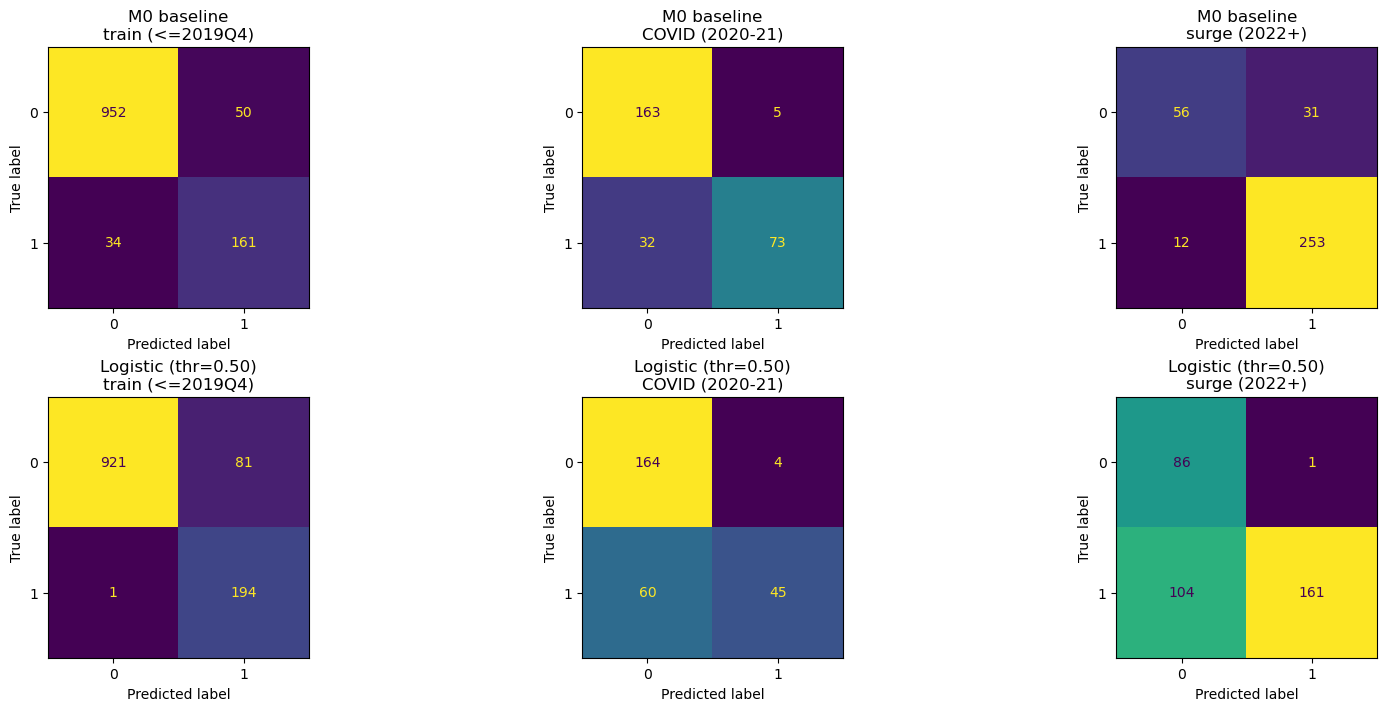

PR curves (logistic) + baseline PR point:


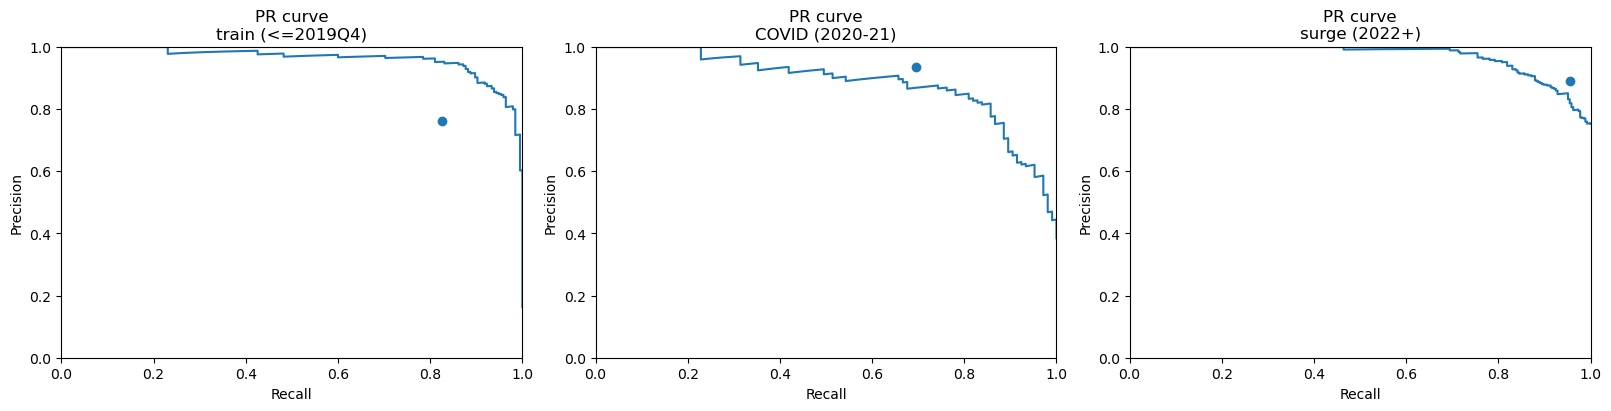

Threshold sweep example (train window):


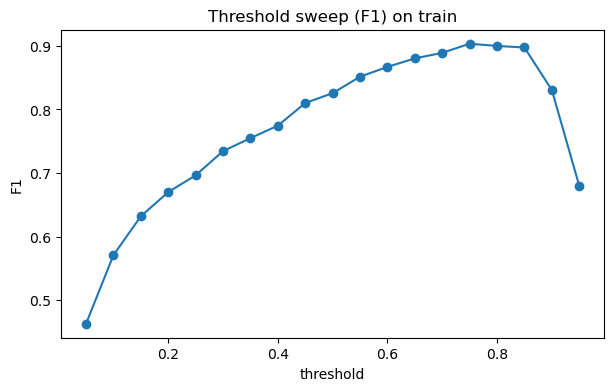

Best threshold by F1: 0.75 | Best F1: 0.903


In [8]:
def plotCMGrid(threshold=0.50):
    windows = [
        ("train (<=2019Q4)", trainMask, validTrain),
        ("COVID (2020-21)",  covidMask, validCovid),
        ("surge (2022+)",    surgeMask, validSurge),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)

    for j, (title, mask, validMask) in enumerate(windows):
        idx = yAll.loc[mask].index
        validAligned = validMask.reindex(idx).fillna(False)

        # baseline
        yTrue = yAll.loc[idx][validAligned].astype(int)
        yPredBase = baselineClassPred.loc[idx][validAligned].astype(int)
        cmBase = confusion_matrix(yTrue, yPredBase, labels=[0, 1])
        ConfusionMatrixDisplay(cmBase, display_labels=[0, 1]).plot(ax=axes[0, j], values_format="d", colorbar=False)
        axes[0, j].set_title(f"M0 baseline\n{title}")

        # logistic
        prob = bestLogit.predict_proba(xAll.loc[idx])[:, 1]
        prob = prob[validAligned.values]
        yPredLog = (prob >= threshold).astype(int)
        cmLog = confusion_matrix(yTrue, yPredLog, labels=[0, 1])
        ConfusionMatrixDisplay(cmLog, display_labels=[0, 1]).plot(ax=axes[1, j], values_format="d", colorbar=False)
        axes[1, j].set_title(f"Logistic (thr={threshold:.2f})\n{title}")

    plt.show()

def plotPRCurves():
    windows = [
        ("train (<=2019Q4)", trainMask, validTrain),
        ("COVID (2020-21)",  covidMask, validCovid),
        ("surge (2022+)",    surgeMask, validSurge),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

    for ax, (title, mask, validMask) in zip(axes, windows):
        idx = yAll.loc[mask].index
        validAligned = validMask.reindex(idx).fillna(False)

        yTrue = yAll.loc[idx][validAligned].astype(int).values
        prob = bestLogit.predict_proba(xAll.loc[idx])[:, 1]
        prob = prob[validAligned.values]

        prec, rec, _ = precision_recall_curve(yTrue, prob)
        ax.plot(rec, prec)

        # baseline single PR point
        yPredBase = baselineClassPred.loc[idx][validAligned].astype(int).values
        tp = ((yPredBase == 1) & (yTrue == 1)).sum()
        basePrec = tp / max((yPredBase == 1).sum(), 1)
        baseRec  = tp / max((yTrue == 1).sum(), 1)
        ax.scatter([baseRec], [basePrec])

        ax.set_title(f"PR curve\n{title}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

    plt.show()

def thresholdSweepF1(mask, validMask, thresholds=None, title=""):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)

    idx = yAll.loc[mask].index
    validAligned = validMask.reindex(idx).fillna(False)

    yTrue = yAll.loc[idx][validAligned].astype(int).values
    prob = bestLogit.predict_proba(xAll.loc[idx])[:, 1]
    prob = prob[validAligned.values]

    f1s = []
    for t in thresholds:
        yPred = (prob >= t).astype(int)
        f1s.append(f1_score(yTrue, yPred, zero_division=0))

    bestIdx = int(np.argmax(f1s))
    bestT = float(thresholds[bestIdx])

    plt.figure(figsize=(7, 4))
    plt.plot(thresholds, f1s, marker="o")
    plt.xlabel("threshold")
    plt.ylabel("F1")
    plt.title(f"Threshold sweep (F1) {title}".strip())
    plt.show()

    print("Best threshold by F1:", round(bestT, 3), "| Best F1:", round(float(f1s[bestIdx]), 3))
    return bestT

print("Confusion matrices (baseline vs logistic @ 0.50):")
plotCMGrid(threshold=0.50)

print("PR curves (logistic) + baseline PR point:")
plotPRCurves()

print("Threshold sweep example (train window):")
bestThrTrain = thresholdSweepF1(trainMask, validTrain, title="on train")


In [9]:
def chooseThresholdByF1(calibMask, validMask, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)

    idx = yAll.loc[calibMask].index
    validAligned = validMask.reindex(idx).fillna(False)

    yTrue = yAll.loc[idx][validAligned].astype(int).values
    prob = bestLogit.predict_proba(xAll.loc[idx])[:, 1]
    prob = prob[validAligned.values]

    rows = []
    for t in thresholds:
        yPred = (prob >= t).astype(int)
        rows.append({
            "threshold": float(t),
            "precision": precision_score(yTrue, yPred, zero_division=0),
            "recall": recall_score(yTrue, yPred, zero_division=0),
            "f1": f1_score(yTrue, yPred, zero_division=0),
        })

    dfThr = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
    bestT = float(dfThr.loc[0, "threshold"])
    print("Chosen threshold (max F1 on calibration window):", bestT)
    display(dfThr.head(8))
    return bestT, dfThr

# Recommended calibration: COVID
bestThrCovid, dfThrCovid = chooseThresholdByF1(covidMask, validCovid)

print("\nLogistic (same valid rows) @ calibrated threshold:")
evalClassPred("train (<=2019Q4)", trainMask, logitPredAtThreshold(trainMask, validTrain, bestThrCovid))
evalClassPred("COVID (2020-21)",  covidMask, logitPredAtThreshold(covidMask, validCovid, bestThrCovid))
evalClassPred("surge (2022+)",    surgeMask, logitPredAtThreshold(surgeMask, validSurge, bestThrCovid))


Chosen threshold (max F1 on calibration window): 0.05


,threshold,precision,recall,f1
0,0.05,0.875000,0.733333,0.797927
1,0.10,0.865854,0.676190,0.759358
2,0.15,0.904110,0.628571,0.741573
3,0.20,0.893939,0.561905,0.690058
4,0.25,0.901639,0.523810,0.662651
5,0.30,0.915254,0.514286,0.658537
6,0.35,0.928571,0.495238,0.645963
7,0.40,0.925926,0.476190,0.628931



Logistic (same valid rows) @ calibrated threshold:

train (<=2019Q4)
  n=1197 | acc=0.622 | bAcc=0.774 | precision=0.301 | recall=1.000 | f1=0.463
  Confusion matrix [[TN FP],[FN TP]]:
[[550 452]
 [  0 195]]

COVID (2020-21)
  n=273 | acc=0.857 | bAcc=0.834 | precision=0.875 | recall=0.733 | f1=0.798
  Confusion matrix [[TN FP],[FN TP]]:
[[157  11]
 [ 28  77]]

surge (2022+)
  n=352 | acc=0.787 | bAcc=0.843 | precision=0.980 | recall=0.732 | f1=0.838
  Confusion matrix [[TN FP],[FN TP]]:
[[ 83   4]
 [ 71 194]]


44      True
45      True
46      True
47      True
48      True
        ... 
1852    True
1853    True
1854    True
1855    True
1856    True
Length: 352, dtype: bool

In [10]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

# -----------------------
# Config
# -----------------------
outDir = reportsTablesPath / "ml_classification_high_inflation"
outDir.mkdir(parents=True, exist_ok=True)

THR = 0.05  # <-- your calibrated threshold; change if you decide otherwise

# -----------------------
# Predictions (row-level)
# -----------------------
dfPred = dfCls[["geo", "timeQuarter"]].copy()
dfPred["y_true"] = dfCls[targetClassCol].astype(int)

# M0 baseline (class persistence)
dfPred["y_pred_m0"] = baselineClassPred  # shifted within geo (has NaN in first quarter per geo)

# Logistic probabilities + thresholded label
dfPred["p_logit"] = bestLogit.predict_proba(dfCls[xCols])[:, 1]
dfPred["y_pred_logit"] = (dfPred["p_logit"] >= THR).astype(int)

# Save row-level predictions
predPath = outDir / "cls_predictions_rowlevel.parquet"
dfPred.to_parquet(predPath, index=False)
print("Saved:", predPath)

# Save model + threshold metadata
joblibPath = outDir / "logit_best_model.joblib"
joblib.dump(bestLogit, joblibPath)
print("Saved:", joblibPath)

metaPath = outDir / "logit_threshold_choice.csv"
pd.DataFrame([{
    "threshold": THR,
    "how_chosen": "max F1 on calibration window (COVID by default)",
    "note": "Low threshold boosts recall; expect more false positives in pre-COVID."
}]).to_csv(metaPath, index=False)
print("Saved:", metaPath)

# -----------------------
# Window metrics (summary)
# -----------------------
def metrics_for_mask(mask, y_true, y_pred_hard, y_prob=None):
    out = {}
    out["n"] = int(mask.sum())
    out["acc"] = accuracy_score(y_true, y_pred_hard)
    out["bacc"] = balanced_accuracy_score(y_true, y_pred_hard)
    out["precision"] = precision_score(y_true, y_pred_hard, zero_division=0)
    out["recall"] = recall_score(y_true, y_pred_hard, zero_division=0)
    out["f1"] = f1_score(y_true, y_pred_hard, zero_division=0)
    out["cm_TN_FP_FN_TP"] = ",".join(map(str, confusion_matrix(y_true, y_pred_hard, labels=[0,1]).ravel()))
    if y_prob is not None and len(np.unique(y_true)) > 1:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
        out["pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan
    out["pos_rate"] = float(np.mean(y_true))
    return out

windows = [
    ("train", trainMask),
    ("covid", covidMask),
    ("surge", surgeMask),
]

rows = []
for wname, wmask in windows:
    # Use SAME valid rows for fair comparison (drop where baseline is NaN)
    idx = dfCls.loc[wmask].index
    valid = dfPred.loc[idx, "y_pred_m0"].notna()

    yT = dfPred.loc[idx, "y_true"][valid].astype(int).values

    # Baseline
    yP0 = dfPred.loc[idx, "y_pred_m0"][valid].astype(int).values
    rows.append({"window": wname, "model": "M0_persistence", **metrics_for_mask(wmask, yT, yP0)})

    # Logistic
    yPL = dfPred.loc[idx, "y_pred_logit"][valid].astype(int).values
    pL = dfPred.loc[idx, "p_logit"][valid].values
    rows.append({"window": wname, "model": f"logit_thr_{THR:.2f}", **metrics_for_mask(wmask, yT, yPL, y_prob=pL)})

dfSummary = pd.DataFrame(rows)
sumPath = outDir / "cls_metrics_summary.csv"
dfSummary.to_csv(sumPath, index=False)
print("Saved:", sumPath)

display(dfSummary)


Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation/cls_predictions_rowlevel.parquet
Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation/logit_best_model.joblib
Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation/logit_threshold_choice.csv
Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation/cls_metrics_summary.csv


,window,model,n,acc,bacc,precision,recall,f1,cm_TN_FP_FN_TP,roc_auc,pr_auc,pos_rate
0,train,M0_persistence,1232,0.929825,0.887870,0.763033,0.825641,0.793103,"952,50,34,161",NaN,NaN,0.162907
1,train,logit_thr_0.05,1232,0.622389,0.774451,0.301391,1.000000,0.463183,"550,452,0,195",0.993260,0.962953,0.162907
2,covid,M0_persistence,273,0.864469,0.832738,0.935897,0.695238,0.797814,"163,5,32,73",NaN,NaN,0.384615
3,covid,logit_thr_0.05,273,0.857143,0.833929,0.875000,0.733333,0.797927,"157,11,28,77",0.919955,0.887376,0.384615
4,surge,M0_persistence,352,0.877841,0.799198,0.890845,0.954717,0.921676,"56,31,12,253",NaN,NaN,0.752841
5,surge,logit_thr_0.05,352,0.786932,0.843049,0.979798,0.732075,0.838013,"83,4,71,194",0.904706,0.970190,0.752841


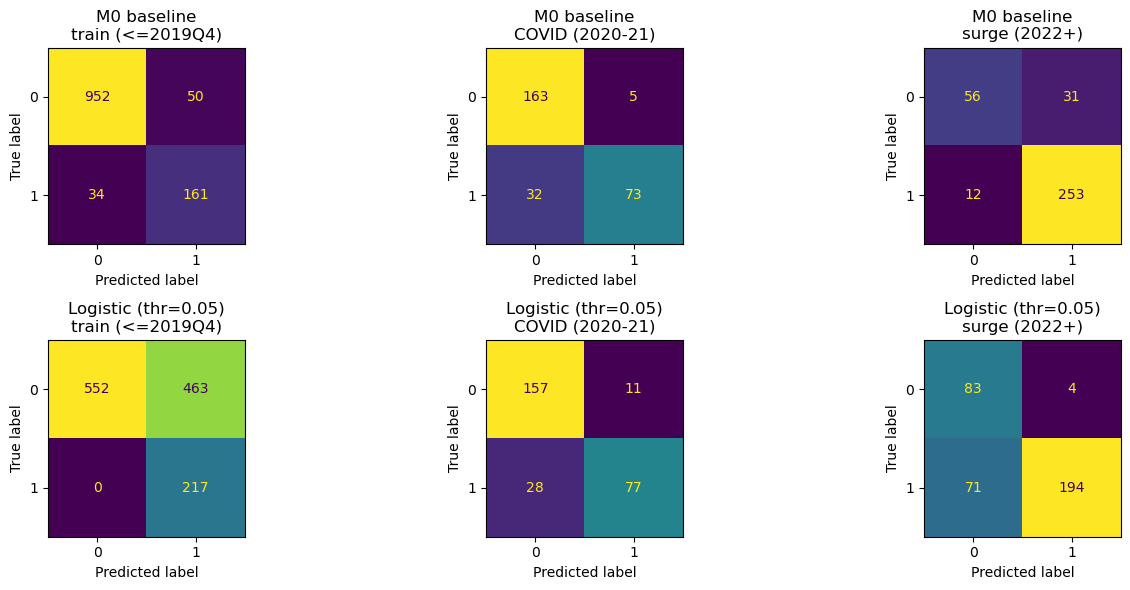

Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/ml_classification_high_inflation/confusion_matrices_M0_vs_logit_thr_0.05.png


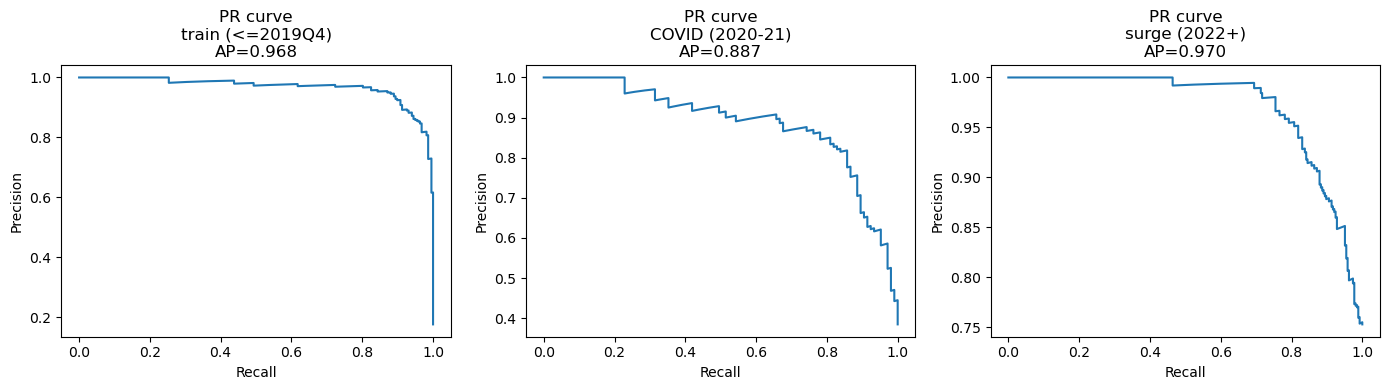

Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/ml_classification_high_inflation/pr_curves_logit.png


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)

FIG_DIR = reportsPath/ "figures" / "ml_classification_high_inflation"
FIG_DIR.mkdir(parents=True, exist_ok=True)

targetCol = "y_high_inflation_next_q"
thr = 0.05  # your chosen threshold

# --- Inputs assumed to exist ---
# dfCls: master modeling df with geo/timeQuarter/features/target
# xAll: dfCls[xModelCols]
# bestLogit: fitted sklearn Pipeline with predict_proba
# masks: trainMask, covidMask, surgeMask

def baseline_class_persistence(df, target_col):
    # predicts y_{t+1} class as y_t within geo -> aligns with rows where lag exists
    return df.groupby("geo")[target_col].shift(1)

def get_window_data(mask):
    y_true = dfCls.loc[mask, targetCol].astype(int)
    # Baseline predictions (may have NaNs for first quarter per geo)
    y_base = baseline_class_persistence(dfCls, targetCol).loc[mask]
    # Logistic probabilities
    p_logit = pd.Series(bestLogit.predict_proba(xAll.loc[mask])[:, 1], index=y_true.index)
    y_logit = (p_logit >= thr).astype(int)
    return y_true, y_base, p_logit, y_logit

windows = [
    ("train (<=2019Q4)", trainMask),
    ("COVID (2020-21)", covidMask),
    ("surge (2022+)", surgeMask),
]

# --- Confusion matrices: baseline vs logistic ---
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for j, (name, mask) in enumerate(windows):
    y_true, y_base, p_logit, y_logit = get_window_data(mask)

    # baseline valid rows only
    valid = y_base.notna()
    cm_base = confusion_matrix(y_true[valid], y_base[valid].astype(int), labels=[0,1])
    ConfusionMatrixDisplay(cm_base, display_labels=[0,1]).plot(ax=axes[0, j], colorbar=False)
    axes[0, j].set_title(f"M0 baseline\n{name}")

    cm_log = confusion_matrix(y_true, y_logit, labels=[0,1])
    ConfusionMatrixDisplay(cm_log, display_labels=[0,1]).plot(ax=axes[1, j], colorbar=False)
    axes[1, j].set_title(f"Logistic (thr={thr:.2f})\n{name}")

plt.tight_layout()
out_cm = FIG_DIR / f"confusion_matrices_M0_vs_logit_thr_{thr:.2f}.png"
plt.savefig(out_cm, dpi=160)
plt.show()
print("Saved:", out_cm)

# --- PR curves (logistic) ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for j, (name, mask) in enumerate(windows):
    y_true, y_base, p_logit, y_logit = get_window_data(mask)
    prec, rec, _ = precision_recall_curve(y_true, p_logit)
    ap = average_precision_score(y_true, p_logit)
    axes[j].plot(rec, prec)
    axes[j].set_title(f"PR curve\n{name}\nAP={ap:.3f}")
    axes[j].set_xlabel("Recall")
    axes[j].set_ylabel("Precision")
plt.tight_layout()
out_pr = FIG_DIR / "pr_curves_logit.png"
plt.savefig(out_pr, dpi=160)
plt.show()
print("Saved:", out_pr)


In [14]:
# -----------------------
# Cell 1 — Load panel + sanity checks + windows + feature lists
# -----------------------

# 1) Load dfCls (auto-pick a parquet in data_processed that contains the needed columns)
parquets = sorted(dataProcessedPath.glob("*.parquet"))
if len(parquets) == 0:
    raise FileNotFoundError(f"No parquet files found in {dataProcessedPath}")

def looks_like_cls_file(p):
    try:
        cols = pd.read_parquet(p, engine="pyarrow", columns=None).columns
    except Exception:
        # fallback: read without engine hint
        cols = pd.read_parquet(p).columns
    need = set(keyCols + [targetClassCol])
    return need.issubset(set(cols))

candidates = [p for p in parquets if looks_like_cls_file(p)]
if len(candidates) == 0:
    raise FileNotFoundError(
        f"No parquet in {dataProcessedPath} contains {keyCols + [targetClassCol]}.\n"
        f"Available: {[p.name for p in parquets]}"
    )

# pick the most recently modified candidate
clsPath = max(candidates, key=lambda p: p.stat().st_mtime)
dfCls = pd.read_parquet(clsPath)
print("Loaded:", clsPath.name, "| shape:", dfCls.shape)

# 2) Enforce expected dtypes + sorting
dfCls = dfCls.copy()
dfCls["geo"] = dfCls["geo"].astype(str)

# Ensure timeQuarter is a PeriodIndex (Quarterly). If already Period, this is safe.
if not isinstance(dfCls["timeQuarter"].dtype, pd.PeriodDtype):
    dfCls["timeQuarter"] = pd.PeriodIndex(dfCls["timeQuarter"].astype(str), freq="Q-DEC")

# Target: 0/1 integer
dfCls = dfCls.dropna(subset=[targetClassCol]).copy()
dfCls[targetClassCol] = dfCls[targetClassCol].astype(int)

dfCls = dfCls.sort_values(["geo", "timeQuarter"]).reset_index(drop=True)

# 3) Basic sanity
print("geo n:", dfCls["geo"].nunique(), "| quarters n:", dfCls["timeQuarter"].nunique())
print("timeQuarter range:", dfCls["timeQuarter"].min(), "->", dfCls["timeQuarter"].max())

# 4) Define evaluation windows (feature-quarter aligned; target is next quarter)
trainEnd = pd.Period("2019Q4", freq="Q-DEC")
covidStart = pd.Period("2020Q1", freq="Q-DEC")
covidEnd = pd.Period("2021Q4", freq="Q-DEC")
surgeStart = pd.Period("2022Q1", freq="Q-DEC")

trainMask = dfCls["timeQuarter"] <= trainEnd
covidMask = (dfCls["timeQuarter"] >= covidStart) & (dfCls["timeQuarter"] <= covidEnd)
surgeMask = dfCls["timeQuarter"] >= surgeStart

# 5) Feature lists (geo treated as categorical fixed-effect; everything else numeric)
catCols = ["geo"]
xCols = [c for c in dfCls.columns if c not in (keyCols + [targetClassCol])]
numCols = [c for c in xCols if c not in catCols]

print("\nFeature counts:")
print("xCols:", len(xCols), "| numCols:", len(numCols), "| catCols:", len(catCols))
print("geo in xCols:", "geo" in xCols)

# 6) Class balance (overall + by window)
def pos_rate(mask):
    s = dfCls.loc[mask, targetClassCol]
    return float(s.mean()), int(s.shape[0])

p_all, n_all = pos_rate(dfCls.index == dfCls.index)
p_tr, n_tr = pos_rate(trainMask)
p_cv, n_cv = pos_rate(covidMask)
p_su, n_su = pos_rate(surgeMask)

print("\nTarget class balance:")
print(f"overall        | n={n_all:4d} | P(y=1)={p_all:0.3f}")
print(f"train (<=2019) | n={n_tr:4d} | P(y=1)={p_tr:0.3f}")
print(f"COVID (20-21)  | n={n_cv:4d} | P(y=1)={p_cv:0.3f}")
print(f"surge (2022+)  | n={n_su:4d} | P(y=1)={p_su:0.3f}")


Loaded: ml_y_macro_income_2010_2024.parquet | shape: (1888, 4)
geo n: 36 | quarters n: 55
timeQuarter range: 2011Q1 -> 2024Q3

Feature counts:
xCols: 1 | numCols: 1 | catCols: 1
geo in xCols: False

Target class balance:
overall        | n=1888 | P(y=1)=0.317
train (<=2019) | n=1263 | P(y=1)=0.181
COVID (20-21)  | n= 273 | P(y=1)=0.385
surge (2022+)  | n= 352 | P(y=1)=0.753


In [18]:
# --- Load X and y ---
dfX = pd.read_parquet(dataProcessedPath / "ml_X_macro_income_2010_2024.parquet")
dfY = pd.read_parquet(dataProcessedPath / "ml_y_macro_income_2010_2024.parquet")

# Keep only the classification target we need (+ keys)
dfY = dfY[keyCols + [targetClassCol]].copy()

# Merge to one modeling table (one row per geo-quarter)
dfCls = (
    dfX.merge(dfY, on=keyCols, how="inner", validate="1:1")
       .sort_values(keyCols)
       .reset_index(drop=True)
)

print("dfX shape:", dfX.shape)
print("dfY shape:", dfY.shape)
print("dfCls shape:", dfCls.shape)
print("Duplicate keys:", dfCls.duplicated(keyCols).sum())
print("Target missing rate:", dfCls[targetClassCol].isna().mean())

# Feature lists (now this will be sane)
xCols = [c for c in dfCls.columns if c not in keyCols + [targetClassCol]]
print("Feature counts:", "xCols:", len(xCols))
print("geo in xCols:", "geo" in xCols)


dfX shape: (1888, 129)
dfY shape: (1888, 3)
dfCls shape: (1888, 130)
Duplicate keys: 0
Target missing rate: 0.0
Feature counts: xCols: 127
geo in xCols: False


In [19]:
import numpy as np

# --- Window masks (same story as regression notebook) ---
trainMask = dfCls["timeQuarter"] <= pd.Period("2019Q4", freq="Q-DEC")
covidMask = (dfCls["timeQuarter"] >= pd.Period("2020Q1", freq="Q-DEC")) & (dfCls["timeQuarter"] <= pd.Period("2021Q4", freq="Q-DEC"))
surgeMask = dfCls["timeQuarter"] >= pd.Period("2022Q1", freq="Q-DEC")

print("Rows per window:")
print(" train (<=2019Q4):", int(trainMask.sum()))
print(" COVID (2020-21): ", int(covidMask.sum()))
print(" surge (>=2022Q1):", int(surgeMask.sum()))

# --- Feature columns (exclude keys + target) ---
xCols = [c for c in dfCls.columns if c not in keyCols + [targetClassCol]]
numCols = [c for c in xCols if c != "geo"]   # geo not present in this reduced-feature dataset; keep pattern consistent
catCols = [c for c in xCols if c == "geo"]

print("\nFeature counts:")
print(f"xCols: {len(xCols)} | numCols: {len(numCols)} | catCols: {len(catCols)}")
print("geo in xCols:", "geo" in xCols)

# --- Quarter-based expanding CV on train pool ---
def makeQuarterSplitsFromTrain(dfTrainPool, nSplits=5, testQuarters=4):
    tq = dfTrainPool["timeQuarter"]
    quarters = np.array(sorted(tq.unique()))
    nQuarters = len(quarters)

    startTrainQuarters = nQuarters - nSplits * testQuarters
    if startTrainQuarters <= 0:
        raise ValueError(f"Not enough quarters for nSplits={nSplits} and testQuarters={testQuarters}")

    splits = []
    for i in range(nSplits):
        trainEnd = startTrainQuarters + i * testQuarters
        trainQuarters = quarters[:trainEnd]
        testQuartersArr = quarters[trainEnd: trainEnd + testQuarters]

        trainIdx = np.where(tq.isin(trainQuarters))[0]
        testIdx  = np.where(tq.isin(testQuartersArr))[0]
        splits.append((trainIdx, testIdx))
    return splits

dfTrainPool = dfCls.loc[trainMask].copy().reset_index(drop=True)
quarterSplits = makeQuarterSplitsFromTrain(dfTrainPool, nSplits=5, testQuarters=4)

print("\nQuarter CV folds:", len(quarterSplits))
print("Fold sizes (train, val):", [(len(tr), len(te)) for tr, te in quarterSplits])


Rows per window:
 train (<=2019Q4): 1263
 COVID (2020-21):  273
 surge (>=2022Q1): 352

Feature counts:
xCols: 127 | numCols: 127 | catCols: 0
geo in xCols: False

Quarter CV folds: 5
Fold sizes (train, val): [(548, 144), (692, 144), (836, 144), (980, 143), (1123, 140)]


In [20]:
# --- M0 baseline: class persistence ---
# Predict y_{t+1} ≈ y_{t} (implemented as lag-1 of the *target label* within each geo)

yAll = dfCls[targetClassCol].astype(int)

baselinePred = dfCls.groupby("geo")[targetClassCol].shift(1)  # NaN for first quarter per geo

def evalClassPred(name, mask, yPredSeries):
    yTrue = yAll.loc[mask]
    yPred = yPredSeries.loc[mask]
    valid = yPred.notna()

    yT = yTrue.loc[valid].astype(int)
    yP = yPred.loc[valid].astype(int)

    cm = confusion_matrix(yT, yP, labels=[0, 1])
    acc  = accuracy_score(yT, yP)
    bacc = balanced_accuracy_score(yT, yP)
    prec = precision_score(yT, yP, zero_division=0)
    rec  = recall_score(yT, yP, zero_division=0)
    f1   = f1_score(yT, yP, zero_division=0)

    print(f"\n{name}")
    print(f"  n={len(yT)} | acc={acc:.3f} | bAcc={bacc:.3f} | precision={prec:.3f} | recall={rec:.3f} | f1={f1:.3f}")
    print("  Confusion matrix [[TN FP],[FN TP]]:")
    print(cm)

print("Baseline (M0) = class persistence")
evalClassPred("train (<=2019Q4)", trainMask, baselinePred)
evalClassPred("COVID (2020-21)", covidMask, baselinePred)
evalClassPred("surge (2022+)", surgeMask, baselinePred)

# Keep these "valid row" masks for apples-to-apples comparison vs Logistic
validTrain = trainMask & baselinePred.notna()
validCovid = covidMask & baselinePred.notna()
validSurge = surgeMask & baselinePred.notna()

print("\nValid rows (baseline not-NaN):",
      int(validTrain.sum()), int(validCovid.sum()), int(validSurge.sum()))


Baseline (M0) = class persistence

train (<=2019Q4)
  n=1227 | acc=0.926 | bAcc=0.884 | precision=0.758 | recall=0.820 | f1=0.788
  Confusion matrix [[TN FP],[FN TP]]:
[[967  54]
 [ 37 169]]

COVID (2020-21)
  n=273 | acc=0.864 | bAcc=0.833 | precision=0.936 | recall=0.695 | f1=0.798
  Confusion matrix [[TN FP],[FN TP]]:
[[163   5]
 [ 32  73]]

surge (2022+)
  n=352 | acc=0.878 | bAcc=0.799 | precision=0.891 | recall=0.955 | f1=0.922
  Confusion matrix [[TN FP],[FN TP]]:
[[ 56  31]
 [ 12 253]]

Valid rows (baseline not-NaN): 1227 273 352


In [21]:
from sklearn.impute import SimpleImputer

# --- Train pool (<=2019Q4) ---
dfTrainPool = dfCls.loc[trainMask].copy().reset_index(drop=True)
xTrain = dfTrainPool[xCols]
yTrain = dfTrainPool[targetClassCol].astype(int)

# --- Preprocess: impute + scale numerics (no geo fixed effects in this dataset) ---
numPipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

transformers = [("num", numPipe, numCols)]
# If you ever add geo back into xCols, this will auto-activate
if len(catCols) > 0:
    catPipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    transformers.append(("cat", catPipe, catCols))

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")

logitPipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=5000, solver="liblinear"))
])

paramGrid = {
    "model__C": [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0],
    "model__class_weight": [None, "balanced"],
}

logitSearch = GridSearchCV(
    estimator=logitPipe,
    param_grid=paramGrid,
    scoring="average_precision",  # PR-AUC
    cv=quarterSplits,
    n_jobs=-1,
    refit=True
)

logitSearch.fit(xTrain, yTrain)
bestLogit = logitSearch.best_estimator_

print("\nBest Logistic params:", logitSearch.best_params_)
print("Best CV PR-AUC (train pool):", round(logitSearch.best_score_, 4))


# --- Evaluation helpers ---
def prob_pred(mask):
    X = dfCls.loc[mask, xCols]
    p = bestLogit.predict_proba(X)[:, 1]
    return pd.Series(p, index=dfCls.index[mask])

def evalLogit(name, mask, threshold=0.50, validMask=None):
    useMask = mask if validMask is None else (mask & validMask)

    yTrue = yAll.loc[useMask].astype(int)
    p = prob_pred(useMask)
    yHat = (p >= threshold).astype(int)

    roc = roc_auc_score(yTrue, p)
    pr  = average_precision_score(yTrue, p)

    cm = confusion_matrix(yTrue, yHat, labels=[0, 1])
    acc  = accuracy_score(yTrue, yHat)
    bacc = balanced_accuracy_score(yTrue, yHat)
    prec = precision_score(yTrue, yHat, zero_division=0)
    rec  = recall_score(yTrue, yHat, zero_division=0)
    f1   = f1_score(yTrue, yHat, zero_division=0)

    print(f"\n{name}")
    print(f"  ROC-AUC: {roc:.3f} | PR-AUC: {pr:.3f} | n={len(yTrue)} | P(y=1)={yTrue.mean():.3f}")
    print(f"  thr={threshold:.2f} | precision={prec:.3f} recall={rec:.3f} f1={f1:.3f} | acc={acc:.3f} bAcc={bacc:.3f}")
    print("  Confusion matrix [[TN FP],[FN TP]]:")
    print(cm)

print("\nLogistic performance @ threshold=0.50 (all rows):")
evalLogit("train (<=2019Q4)", trainMask, threshold=0.50)
evalLogit("COVID (2020-21)", covidMask, threshold=0.50)
evalLogit("surge (2022+)", surgeMask, threshold=0.50)

print("\nLogistic performance @ threshold=0.50 (same valid rows as baseline):")
evalLogit("train (<=2019Q4)", trainMask, threshold=0.50, validMask=baselinePred.notna())
evalLogit("COVID (2020-21)", covidMask, threshold=0.50, validMask=baselinePred.notna())
evalLogit("surge (2022+)", surgeMask, threshold=0.50, validMask=baselinePred.notna())



Best Logistic params: {'model__C': 0.05, 'model__class_weight': None}
Best CV PR-AUC (train pool): 0.6309

Logistic performance @ threshold=0.50 (all rows):

train (<=2019Q4)
  ROC-AUC: 0.976 | PR-AUC: 0.912 | n=1263 | P(y=1)=0.181
  thr=0.50 | precision=0.842 recall=0.817 f1=0.829 | acc=0.939 bAcc=0.891
  Confusion matrix [[TN FP],[FN TP]]:
[[999  35]
 [ 42 187]]

COVID (2020-21)
  ROC-AUC: 0.946 | PR-AUC: 0.914 | n=273 | P(y=1)=0.385
  thr=0.50 | precision=0.971 recall=0.314 f1=0.475 | acc=0.733 bAcc=0.654
  Confusion matrix [[TN FP],[FN TP]]:
[[167   1]
 [ 72  33]]

surge (2022+)
  ROC-AUC: 0.944 | PR-AUC: 0.982 | n=352 | P(y=1)=0.753
  thr=0.50 | precision=0.993 recall=0.574 f1=0.727 | acc=0.676 bAcc=0.781
  Confusion matrix [[TN FP],[FN TP]]:
[[ 86   1]
 [113 152]]

Logistic performance @ threshold=0.50 (same valid rows as baseline):

train (<=2019Q4)
  ROC-AUC: 0.975 | PR-AUC: 0.901 | n=1227 | P(y=1)=0.168
  thr=0.50 | precision=0.833 recall=0.801 f1=0.817 | acc=0.940 bAcc=0.884

Chosen threshold (max F1 on COVID calibration): 0.01


,threshold,precision,recall,f1
0,0.010000,0.760000,0.904762,0.826087
1,0.035789,0.858696,0.752381,0.802030
2,0.061579,0.911392,0.685714,0.782609
3,0.087368,0.945205,0.657143,0.775281
4,0.113158,0.941176,0.609524,0.739884
5,0.138947,0.950820,0.552381,0.698795
6,0.164737,0.948276,0.523810,0.674847
7,0.190526,0.961538,0.476190,0.636943
8,0.216316,0.960784,0.466667,0.628205
9,0.242105,0.979592,0.457143,0.623377



Logistic (same valid rows) @ calibrated threshold:

train (<=2019Q4)
  ROC-AUC: 0.975 | PR-AUC: 0.901 | n=1227 | P(y=1)=0.168
  thr=0.01 | precision=0.193 recall=1.000 f1=0.324 | acc=0.299 bAcc=0.579
  Confusion matrix [[TN FP],[FN TP]]:
[[161 860]
 [  0 206]]

COVID (2020-21)
  ROC-AUC: 0.946 | PR-AUC: 0.914 | n=273 | P(y=1)=0.385
  thr=0.01 | precision=0.760 recall=0.905 f1=0.826 | acc=0.853 bAcc=0.863
  Confusion matrix [[TN FP],[FN TP]]:
[[138  30]
 [ 10  95]]

surge (2022+)
  ROC-AUC: 0.944 | PR-AUC: 0.982 | n=352 | P(y=1)=0.753
  thr=0.01 | precision=0.978 recall=0.838 f1=0.902 | acc=0.864 bAcc=0.890
  Confusion matrix [[TN FP],[FN TP]]:
[[ 82   5]
 [ 43 222]]


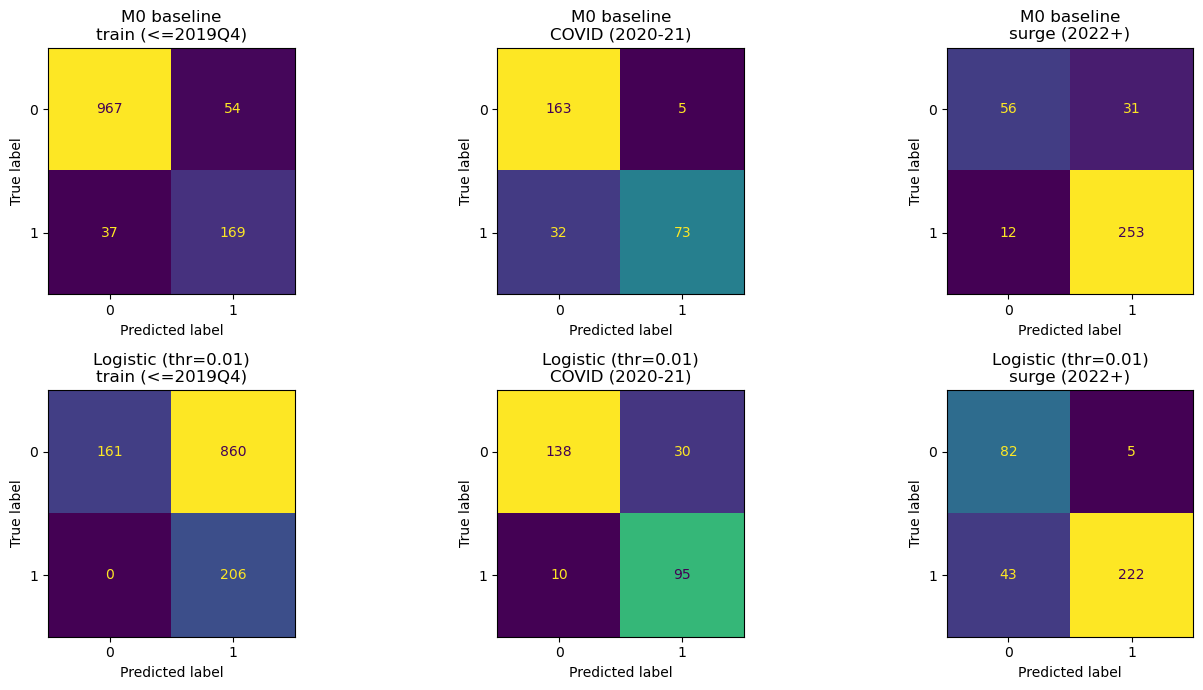

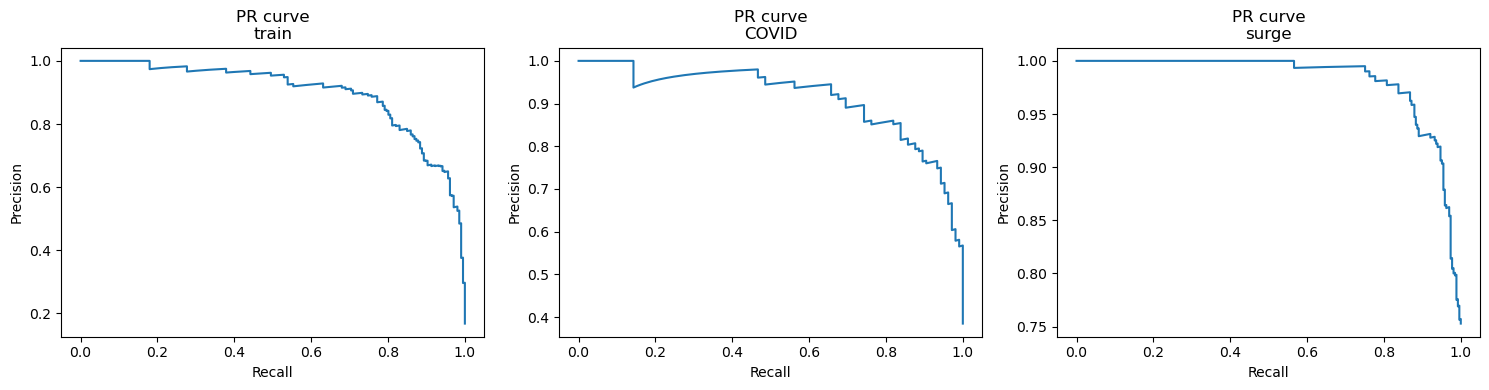

In [22]:
def threshold_sweep(mask, thresholds=np.linspace(0.01, 0.50, 20), validMask=None):
    useMask = mask if validMask is None else (mask & validMask)
    yTrue = yAll.loc[useMask].astype(int)
    p = prob_pred(useMask)

    rows = []
    for thr in thresholds:
        yHat = (p >= thr).astype(int)
        rows.append({
            "threshold": float(thr),
            "precision": precision_score(yTrue, yHat, zero_division=0),
            "recall": recall_score(yTrue, yHat, zero_division=0),
            "f1": f1_score(yTrue, yHat, zero_division=0),
        })
    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)

# Choose threshold on COVID (calibration window)
thrTable = threshold_sweep(covidMask, thresholds=np.linspace(0.01, 0.50, 20), validMask=baselinePred.notna())
bestRow = thrTable.loc[thrTable["f1"].idxmax()]
bestThr = float(bestRow["threshold"])

print("Chosen threshold (max F1 on COVID calibration):", bestThr)
display(thrTable)

print("\nLogistic (same valid rows) @ calibrated threshold:")
evalLogit("train (<=2019Q4)", trainMask, threshold=bestThr, validMask=baselinePred.notna())
evalLogit("COVID (2020-21)", covidMask, threshold=bestThr, validMask=baselinePred.notna())
evalLogit("surge (2022+)", surgeMask, threshold=bestThr, validMask=baselinePred.notna())

# --- Plots: Confusion matrices for Baseline vs Logistic on each window (same valid rows) ---
def plot_cm(title, yTrue, yHat, ax):
    cm = confusion_matrix(yTrue, yHat, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for j, (name, mask) in enumerate([("train (<=2019Q4)", trainMask), ("COVID (2020-21)", covidMask), ("surge (2022+)", surgeMask)]):
    useMask = mask & baselinePred.notna()
    yT = yAll.loc[useMask].astype(int)

    # Baseline
    yB = baselinePred.loc[useMask].astype(int)
    plot_cm(f"M0 baseline\n{name}", yT, yB, axes[0, j])

    # Logistic @ bestThr
    p = prob_pred(useMask)
    yL = (p >= bestThr).astype(int)
    plot_cm(f"Logistic (thr={bestThr:.2f})\n{name}", yT, yL, axes[1, j])

plt.tight_layout()
plt.show()

# --- PR curves (Logistic) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, mask) in zip(axes, [("train", trainMask), ("COVID", covidMask), ("surge", surgeMask)]):
    useMask = mask & baselinePred.notna()
    yT = yAll.loc[useMask].astype(int)
    p = prob_pred(useMask)

    prec, rec, thr = precision_recall_curve(yT, p)
    ax.plot(rec, prec)
    ax.set_title(f"PR curve\n{name}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")

plt.tight_layout()
plt.show()


In [24]:
# --- 2025 features table (scenario-fixed: freeze X at last available quarter) ---
lastQ = dfCls["timeQuarter"].max()
print("last available feature quarter:", lastQ)

# IMPORTANT: keep geo + features only (no timeQuarter here)
dfLastX = (
    dfCls.loc[dfCls["timeQuarter"] == lastQ, ["geo"] + xCols]
    .sort_values("geo")
    .reset_index(drop=True)
)

forecastQuarters = pd.period_range("2025Q1", "2025Q4", freq="Q-DEC")

dfX_2025 = (
    dfLastX.assign(_k=1)
    .merge(pd.DataFrame({"timeQuarter": forecastQuarters, "_k": 1}), on="_k", how="outer")
    .drop(columns="_k")
    .sort_values(["geo", "timeQuarter"])
    .reset_index(drop=True)
)

print(dfX_2025.shape)
print(dfX_2025.columns[:8])
dfX_2025.head()


last available feature quarter: 2024Q3
(128, 129)
Index(['geo', 'hicpIndex', 'hicpInflation', 'employmentIndex',
       'hicp_nMonths_min', 'inc_share_bottom20', 'inc_share_lowmid20',
       'inc_share_mid20'],
      dtype='object')


,geo,hicpIndex,hicpInflation,employmentIndex,hicp_nMonths_min,inc_share_bottom20,inc_share_lowmid20,inc_share_mid20,inc_share_top20,inc_share_upmid20,...,inc_top_bottom_ratio_lag4,inc_top_bottom_ratio_chg_qoq,inc_top_bottom_ratio_chg_yoy,inc_top_bottom_ratio_roll4_mean,inc_top_bottom_ratio_roll4_std,inc_top_bottom_ratio_mom,is_gfc_eurodebt,is_covid,is_infl_surge,timeQuarter
0,AT,133.95,2.366667,104.2,3,8.5,14.0,18.1,37.2,22.3,...,4.329412,0.0,0.047059,4.364706,0.023529,0.011765,0,0,0,2025Q1
1,AT,133.95,2.366667,104.2,3,8.5,14.0,18.1,37.2,22.3,...,4.329412,0.0,0.047059,4.364706,0.023529,0.011765,0,0,0,2025Q2
2,AT,133.95,2.366667,104.2,3,8.5,14.0,18.1,37.2,22.3,...,4.329412,0.0,0.047059,4.364706,0.023529,0.011765,0,0,0,2025Q3
3,AT,133.95,2.366667,104.2,3,8.5,14.0,18.1,37.2,22.3,...,4.329412,0.0,0.047059,4.364706,0.023529,0.011765,0,0,0,2025Q4
4,BE,131.9,4.666667,110.7,3,9.9,14.4,18.4,34.3,22.8,...,3.43,0.0,0.034646,3.455985,0.017323,0.008662,0,0,0,2025Q1


In [25]:
# --- 2025 baseline (M0) table ---
lastY = (
    dfCls[dfCls["timeQuarter"] == lastQ][["geo", targetClassCol]]
    .rename(columns={targetClassCol: "yPred"})
    .copy()
)

dfBase2025 = (
    lastY.assign(_k=1)
    .merge(pd.DataFrame({"timeQuarter": forecastQuarters, "_k": 1}), on="_k", how="outer")
    .drop(columns="_k")
    .assign(model="M0_persistence_2025_flat")
    .sort_values(["geo", "timeQuarter"])
    .reset_index(drop=True)
)

dfBase2025.head()


,geo,yPred,timeQuarter,model
0,AT,0,2025Q1,M0_persistence_2025_flat
1,AT,0,2025Q2,M0_persistence_2025_flat
2,AT,0,2025Q3,M0_persistence_2025_flat
3,AT,0,2025Q4,M0_persistence_2025_flat
4,BE,1,2025Q1,M0_persistence_2025_flat


In [28]:
# ---------- 2025 forecasts (scenario-fixed X at last available quarter) ----------
# Requires: dfCls, xCols, bestLogit, outDir, targetClassCol

lastQ = dfCls["timeQuarter"].max()
print("last available quarter:", lastQ)

# Cross-join last available X (by geo) with 2025Q1..2025Q4
forecastQuarters = pd.period_range("2025Q1", "2025Q4", freq="Q-DEC").astype(str)

dfLastX = (
    dfCls.loc[dfCls["timeQuarter"] == lastQ, ["geo"] + xCols]
    .sort_values("geo")
    .reset_index(drop=True)
)

dfX_2025 = (
    dfLastX.assign(_k=1)
    .merge(pd.DataFrame({"timeQuarter": forecastQuarters, "_k": 1}), on="_k", how="outer")
    .drop(columns="_k")
    .sort_values(["geo", "timeQuarter"])
    .reset_index(drop=True)
)

assert "timeQuarter" in dfX_2025.columns, f"timeQuarter missing, cols={dfX_2025.columns.tolist()[:20]}"

print("dfX_2025:", dfX_2025.shape)
display(dfX_2025[["geo","timeQuarter"]].head())

# ----- Logistic 2025 predictions -----
thrChosen = float(bestThr)  # assumes it exists already

p = bestLogit.predict_proba(dfX_2025[xCols])[:, 1]

dfLogit2025 = (
    dfX_2025[["geo", "timeQuarter"]]
    .assign(
        yProb=p,
        yPred=(p >= thrChosen).astype(int),
        model=f"logit_thr_{thrChosen:.3f}_scenarioFixedX_2025"
    )
)

# ----- Baseline (M0 persistence) 2025 predictions -----
lastY = (
    dfCls.loc[dfCls["timeQuarter"] == lastQ, ["geo", targetClassCol]]
    .rename(columns={targetClassCol: "yPred"})
    .copy()
)

dfBase2025 = (
    lastY.assign(_k=1)
    .merge(pd.DataFrame({"timeQuarter": forecastQuarters, "_k": 1}), on="_k", how="outer")
    .drop(columns="_k")
    .assign(model="M0_persistence_2025_flat")
    .sort_values(["geo", "timeQuarter"])
    .reset_index(drop=True)
)

# ----- Save -----
dfLogit2025.to_parquet(outDir / "cls_forecast_2025_logit.parquet", index=False)
dfBase2025.to_parquet(outDir / "cls_forecast_2025_M0_persistence.parquet", index=False)

print("Saved to:", outDir)
print("Logit head:")
display(dfLogit2025.head())
print("Baseline head:")
display(dfBase2025.head())


last available quarter: 2024Q3
dfX_2025: (128, 129)


,geo,timeQuarter
0,AT,2025Q1
1,AT,2025Q2
2,AT,2025Q3
3,AT,2025Q4
4,BE,2025Q1


Saved to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation
Logit head:


,geo,timeQuarter,yProb,yPred,model
0,AT,2025Q1,0.000191,0,logit_thr_0.010_scenarioFixedX_2025
1,AT,2025Q2,0.000191,0,logit_thr_0.010_scenarioFixedX_2025
2,AT,2025Q3,0.000191,0,logit_thr_0.010_scenarioFixedX_2025
3,AT,2025Q4,0.000191,0,logit_thr_0.010_scenarioFixedX_2025
4,BE,2025Q1,0.162321,1,logit_thr_0.010_scenarioFixedX_2025


Baseline head:


,geo,yPred,timeQuarter,model
0,AT,0,2025Q1,M0_persistence_2025_flat
1,AT,0,2025Q2,M0_persistence_2025_flat
2,AT,0,2025Q3,M0_persistence_2025_flat
3,AT,0,2025Q4,M0_persistence_2025_flat
4,BE,1,2025Q1,M0_persistence_2025_flat


In [30]:
df2025_all = pd.concat(
    [
        dfLogit2025.assign(model="logit_thr_0.010_scenarioFixedX_2025"),
        dfBase2025.assign(yProb=np.nan)  # baseline has no probability
    ],
    ignore_index=True
)

df2025_all.to_parquet(outDir / "cls_forecast_2025_ALL_models.parquet", index=False)
print("Saved:", outDir / "cls_forecast_2025_ALL_models.parquet")
df2025_all.head()


Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation/cls_forecast_2025_ALL_models.parquet


,geo,timeQuarter,yProb,yPred,model
0,AT,2025Q1,0.000191,0,logit_thr_0.010_scenarioFixedX_2025
1,AT,2025Q2,0.000191,0,logit_thr_0.010_scenarioFixedX_2025
2,AT,2025Q3,0.000191,0,logit_thr_0.010_scenarioFixedX_2025
3,AT,2025Q4,0.000191,0,logit_thr_0.010_scenarioFixedX_2025
4,BE,2025Q1,0.162321,1,logit_thr_0.010_scenarioFixedX_2025


In [31]:
print(dfLogit2025["yProb"].describe())
print("\nShare predicted high inflation:", dfLogit2025["yPred"].mean())

# by country ranking
dfLogit2025.groupby("geo")["yProb"].mean().sort_values(ascending=False).head(10)


count    128.000000
mean       0.007912
std        0.028528
min        0.000003
25%        0.000140
50%        0.000616
75%        0.002037
max        0.162321
Name: yProb, dtype: float64

Share predicted high inflation: 0.15625


geo
BE    0.162321
RO    0.029677
PL    0.017200
NL    0.012884
RS    0.010665
PT    0.003414
EL    0.003148
HR    0.002071
SK    0.002026
EE    0.001685
Name: yProb, dtype: float64

In [32]:
meta = pd.DataFrame([{
    "target": targetClassCol,
    "train_end": "2019Q4",
    "calibration_window": "COVID 2020-21",
    "threshold": 0.01,
    "best_C": 0.05,
    "scenario_2025": "fixed X at last available quarter (2024Q3)"
}])

meta.to_csv(outDir / "cls_model_metadata.csv", index=False)
print("Saved:", outDir / "cls_model_metadata.csv")


Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation/cls_model_metadata.csv


In [33]:
# --- Helpers: evaluation + plots ---

def eval_binary(y_true, y_prob=None, y_pred=None):
    out = {}
    out["acc"]  = accuracy_score(y_true, y_pred)
    out["bacc"] = balanced_accuracy_score(y_true, y_pred)
    out["precision"] = precision_score(y_true, y_pred, zero_division=0)
    out["recall"]    = recall_score(y_true, y_pred, zero_division=0)
    out["f1"]        = f1_score(y_true, y_pred, zero_division=0)
    out["cm"]        = confusion_matrix(y_true, y_pred)
    if y_prob is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
        out["pr_auc"]  = average_precision_score(y_true, y_prob)
    return out

def plot_confmats(rows, title_prefix=""):
    # rows = list of (name, y_true, y_pred)
    n = len(rows)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    for ax, (name, yT, yP) in zip(axes, rows):
        ConfusionMatrixDisplay.from_predictions(yT, yP, ax=ax, colorbar=False)
        ax.set_title(f"{title_prefix}{name}")
    plt.tight_layout()
    plt.show()

def plot_pr_curves(rows, title_prefix=""):
    # rows = list of (name, y_true, y_prob, thr_marker)
    n = len(rows)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    for ax, (name, yT, yProb, thr) in zip(axes, rows):
        prec, rec, thrs = precision_recall_curve(yT, yProb)
        ax.plot(rec, prec)
        # marker at chosen threshold (nearest)
        if thr is not None and len(thrs) > 0:
            j = np.argmin(np.abs(thrs - thr))
            ax.scatter(rec[j], prec[j])
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(f"{title_prefix}{name}")
    plt.tight_layout()
    plt.show()

def threshold_sweep(y_true, y_prob, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.80, 40)
    rows = []
    for t in grid:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": float(t),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "bacc": balanced_accuracy_score(y_true, y_pred),
        })
    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)


In [34]:
# Compare how often they disagree in 2025
cmp = (dfBase2025[["geo","timeQuarter","yPred"]]
       .merge(dfLogit2025[["geo","timeQuarter","yPred","yProb"]], on=["geo","timeQuarter"],
              suffixes=("_M0","_logit")))

cmp["disagree"] = (cmp["yPred_M0"] != cmp["yPred_logit"]).astype(int)

print("Disagreement rate:", cmp["disagree"].mean())
cmp.sort_values(["disagree","yProb"], ascending=[False, False]).head(20)


Disagreement rate: 0.21875


,geo,timeQuarter,yPred_M0,yPred_logit,yProb,disagree
104,PT,2025Q1,1,0,0.003414,1
105,PT,2025Q2,1,0,0.003414,1
106,PT,2025Q3,1,0,0.003414,1
107,PT,2025Q4,1,0,0.003414,1
40,EL,2025Q1,1,0,0.003148,1
41,EL,2025Q2,1,0,0.003148,1
42,EL,2025Q3,1,0,0.003148,1
43,EL,2025Q4,1,0,0.003148,1
60,HR,2025Q1,1,0,0.002071,1
61,HR,2025Q2,1,0,0.002071,1


In [35]:
import numpy as np
import pandas as pd

# --- time masks using proper quarter ordering ---
q = pd.PeriodIndex(dfCls["timeQuarter"].astype(str), freq="Q-DEC")
trainMask = q <= pd.Period("2019Q4", freq="Q-DEC")
covidMask = (q >= pd.Period("2020Q1", freq="Q-DEC")) & (q <= pd.Period("2021Q4", freq="Q-DEC"))
surgeMask = q >= pd.Period("2022Q1", freq="Q-DEC")

# --- baseline M0: class persistence (lag-1) ---
dfCls = dfCls.sort_values(["geo", "timeQuarter"]).reset_index(drop=True)
dfCls["y_lag1"] = dfCls.groupby("geo")[targetClassCol].shift(1)
dfCls["yPred_M0"] = dfCls["y_lag1"]  # NaN for first quarter per geo
validM0 = dfCls["yPred_M0"].notna()

print("Rows:", len(dfCls))
print("Train/COVID/Surge:", trainMask.sum(), covidMask.sum(), surgeMask.sum())
print("Valid baseline rows (train/covid/surge):",
      (trainMask & validM0).sum(), (covidMask & validM0).sum(), (surgeMask & validM0).sum())


Rows: 1888
Train/COVID/Surge: 1263 273 352
Valid baseline rows (train/covid/surge): 1227 273 352


In [36]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score, balanced_accuracy_score
)

def eval_from_pred(name, y_true, y_pred, y_prob=None):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()

    out = {
        "window": name,
        "n": int(len(y_true)),
        "acc": accuracy_score(y_true, y_pred),
        "bacc": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "cm_TN_FP_FN_TP": f"{tn},{fp},{fn},{tp}",
        "pos_rate": float(y_true.mean())
    }
    if y_prob is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
        out["pr_auc"]  = average_precision_score(y_true, y_prob)
    return out

def threshold_sweep(y_true, y_prob, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.50, 20)  # keep it focused; adjust if you want
    rows = []
    for t in grid:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": float(t),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)


In [37]:
def make_quarter_cv_splits(df_train, n_folds=5, val_quarters=4):
    qq = pd.PeriodIndex(df_train["timeQuarter"].astype(str), freq="Q-DEC")
    quarters = np.array(sorted(pd.unique(qq)))

    need = n_folds * val_quarters + 1
    assert len(quarters) >= need, f"Not enough quarters. Have={len(quarters)}, need>={need}"

    splits = []
    for k in range(n_folds):
        val_start = len(quarters) - (n_folds - k) * val_quarters
        val_end   = val_start + val_quarters
        val_q = set(quarters[val_start:val_end])

        train_q = set(quarters[:val_start])

        tr_idx = np.where(qq.isin(list(train_q)))[0]
        va_idx = np.where(qq.isin(list(val_q)))[0]
        splits.append((tr_idx, va_idx))
    return splits

dfTrainPool = dfCls.loc[trainMask & validM0].copy().reset_index(drop=True)
cvSplits = make_quarter_cv_splits(dfTrainPool, n_folds=5, val_quarters=4)
print("Fold sizes:", [(len(a), len(b)) for a, b in cvSplits])


Fold sizes: [(513, 143), (656, 144), (800, 144), (944, 143), (1087, 140)]


In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

X_train = dfTrainPool[xCols]
y_train = dfTrainPool[targetClassCol].astype(int)

try:
    from xgboost import XGBClassifier

    gbt = XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )

    pipe_gbt = Pipeline([("model", gbt)])

    paramGrid = {
        "model__max_depth": [2, 3, 4],
        "model__learning_rate": [0.03, 0.05, 0.08],
        "model__subsample": [0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.9, 1.0],
    }

    print("Using XGBoost")

except Exception as e:
    from sklearn.ensemble import HistGradientBoostingClassifier

    gbt = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=3,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        random_state=42
    )

    pipe_gbt = Pipeline([("model", gbt)])

    paramGrid = {
        "model__learning_rate": [0.03, 0.05, 0.08],
        "model__max_depth": [2, 3, 4],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__min_samples_leaf": [20, 30, 50],
    }

    print("Using HistGradientBoosting (xgboost not available)")

gbtSearch = GridSearchCV(
    estimator=pipe_gbt,
    param_grid=paramGrid,
    cv=cvSplits,
    scoring="average_precision",   # PR-AUC focus
    n_jobs=-1,
    refit=True
)

gbtSearch.fit(X_train, y_train)
bestGBT = gbtSearch.best_estimator_

print("Best GBT params:", gbtSearch.best_params_)
print("Best CV PR-AUC (train pool):", round(gbtSearch.best_score_, 4))


Using HistGradientBoosting (xgboost not available)
Best GBT params: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__max_leaf_nodes': 15, 'model__min_samples_leaf': 50}
Best CV PR-AUC (train pool): 0.8482


In [40]:
def get_probs(estimator, df_subset):
    return estimator.predict_proba(df_subset[xCols])[:, 1]

# probs on each window (aligned to baseline-valid rows)
df_train = dfCls.loc[trainMask & validM0].copy()
df_covid = dfCls.loc[covidMask & validM0].copy()
df_surge = dfCls.loc[surgeMask & validM0].copy()

p_train = get_probs(bestGBT, df_train)
p_covid = get_probs(bestGBT, df_covid)
p_surge = get_probs(bestGBT, df_surge)

# threshold selection on COVID (F1)
sweep = threshold_sweep(df_covid[targetClassCol].astype(int).values, p_covid)
thr_gbt = float(sweep.loc[0, "threshold"])
print("Chosen GBT threshold (max F1 on COVID):", thr_gbt)
display(sweep.head(10))

# evaluate with that threshold
rows = []
for name, dfw, pw in [("train", df_train, p_train), ("covid", df_covid, p_covid), ("surge", df_surge, p_surge)]:
    yT = dfw[targetClassCol].astype(int).values
    yP = (pw >= thr_gbt).astype(int)
    rows.append(eval_from_pred(name, yT, yP, y_prob=pw))

df_gbt_metrics = pd.DataFrame(rows)
df_gbt_metrics


Chosen GBT threshold (max F1 on COVID): 0.08736842105263157


,threshold,precision,recall,f1
0,0.087368,0.879630,0.904762,0.892019
1,0.061579,0.838983,0.942857,0.887892
2,0.113158,0.906250,0.828571,0.865672
3,0.035789,0.792000,0.942857,0.860870
4,0.216316,0.942529,0.780952,0.854167
5,0.190526,0.942529,0.780952,0.854167
6,0.242105,0.942529,0.780952,0.854167
7,0.267895,0.952941,0.771429,0.852632
8,0.164737,0.931818,0.780952,0.849741
9,0.138947,0.931818,0.780952,0.849741


,window,n,acc,bacc,precision,recall,f1,cm_TN_FP_FN_TP,pos_rate,roc_auc,pr_auc
0,train,1227,0.871231,0.920687,0.566298,0.995146,0.721831,"864,157,1,205",0.167889,0.987662,0.949568
1,covid,273,0.915751,0.913690,0.879630,0.904762,0.892019,"155,13,10,95",0.384615,0.967347,0.945006
2,surge,352,0.840909,0.697463,0.836013,0.981132,0.902778,"36,51,5,260",0.752841,0.926003,0.968802


In [41]:
# If you don't have bestLogit in memory, load it:
# import joblib
# bestLogit = joblib.load(outDir / "logit_best_model.joblib")

def logit_probs(df_subset):
    return bestLogit.predict_proba(df_subset[xCols])[:, 1]

pL_train = logit_probs(df_train)
pL_covid = logit_probs(df_covid)
pL_surge = logit_probs(df_surge)

pE_train = 0.5 * (pL_train + p_train)
pE_covid = 0.5 * (pL_covid + p_covid)
pE_surge = 0.5 * (pL_surge + p_surge)

sweepE = threshold_sweep(df_covid[targetClassCol].astype(int).values, pE_covid)
thr_ens = float(sweepE.loc[0, "threshold"])
print("Chosen ENSEMBLE threshold (max F1 on COVID):", thr_ens)
display(sweepE.head(10))

rows = []
for name, dfw, pw in [("train", df_train, pE_train), ("covid", df_covid, pE_covid), ("surge", df_surge, pE_surge)]:
    yT = dfw[targetClassCol].astype(int).values
    yP = (pw >= thr_ens).astype(int)
    r = eval_from_pred(name, yT, yP, y_prob=pw)
    r["model"] = "ensemble_avg_logit_gbt"
    rows.append(r)

df_ens_metrics = pd.DataFrame(rows)
df_ens_metrics


Chosen ENSEMBLE threshold (max F1 on COVID): 0.035789473684210524


,threshold,precision,recall,f1
0,0.035789,0.846154,0.942857,0.891892
1,0.061579,0.875000,0.866667,0.870813
2,0.113158,0.943820,0.800000,0.865979
3,0.087368,0.923913,0.809524,0.862944
4,0.138947,0.953488,0.780952,0.858639
5,0.164737,0.951807,0.752381,0.840426
6,0.190526,0.951807,0.752381,0.840426
7,0.216316,0.950000,0.723810,0.821622
8,0.267895,0.949367,0.714286,0.815217
9,0.242105,0.949367,0.714286,0.815217


,window,n,acc,bacc,precision,recall,f1,cm_TN_FP_FN_TP,pos_rate,roc_auc,pr_auc,model
0,train,1227,0.639772,0.783546,0.317901,1.000000,0.482436,"579,442,0,206",0.167889,0.983711,0.935293,ensemble_avg_logit_gbt
1,covid,273,0.912088,0.917857,0.846154,0.942857,0.891892,"150,18,6,99",0.384615,0.966723,0.941642,ensemble_avg_logit_gbt
2,surge,352,0.829545,0.670614,0.823344,0.984906,0.896907,"31,56,4,261",0.752841,0.948688,0.983480,ensemble_avg_logit_gbt


In [42]:
import json, joblib
import pandas as pd
from datetime import datetime

run_id = datetime.utcnow().strftime("%Y%m%d_%H%M%S")
run_dir = outDir / f"run_{run_id}"
run_dir.mkdir(parents=True, exist_ok=True)

# --- metadata (keeps your future self sane) ---
meta = {
    "run_id": run_id,
    "target": targetClassCol,
    "features_n": len(xCols),
    "cv_folds": getattr(cv, "n_splits", None) if "cv" in globals() else None,
    "notes": "GBT=HistGradientBoosting; thresholds chosen by max F1 on COVID window; scenarioFixedX for 2025."
}
(run_dir / "run_metadata.json").write_text(json.dumps(meta, indent=2))

# --- models ---
if "bestLogit" in globals():
    joblib.dump(bestLogit, run_dir / "model_logit.joblib")
if "bestGBT" in globals():
    joblib.dump(bestGBT, run_dir / "model_gbt.joblib")

# --- tables you should always keep ---
if "dfMetricsAll" in globals():
    dfMetricsAll.to_csv(run_dir / "cls_metrics_summary.csv", index=False)

if "dfPredRow" in globals():
    dfPredRow.to_parquet(run_dir / "cls_predictions_rowlevel.parquet", index=False)

# --- forecasts (save whatever exists) ---
for name in ["dfBase2025", "dfLogit2025", "dfGbt2025", "dfEns2025"]:
    if name in globals():
        globals()[name].to_parquet(run_dir / f"{name}.parquet", index=False)

print("Saved run bundle to:", run_dir)


Saved run bundle to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation/run_20251218_205903


In [47]:
[k for k in globals().keys() if "gbt" in k.lower() or "grid" in k.lower() or "search" in k.lower() or "gs" in k.lower()]


['GridSearchCV',
 'paramGrid',
 'logitSearch',
 'plotCMGrid',
 'gbt',
 'pipe_gbt',
 'gbtSearch',
 'bestGBT',
 'thr_gbt',
 'df_gbt_metrics']

In [49]:
import json, joblib
from datetime import datetime
from IPython.display import display

# --- helpers ---
def as_q(x):
    return pd.Period(str(x), freq="Q-DEC")

def eval_binary_block(name, y_true, y_prob, y_pred):
    y_true = y_true.astype(int).to_numpy()
    y_pred = y_pred.astype(int).to_numpy()
    y_prob = np.asarray(y_prob, dtype=float)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # AUCs only make sense if:
    # - y_true has both classes
    # - y_prob has at least some finite values
    can_auc = (len(np.unique(y_true)) > 1) and np.isfinite(y_prob).any()

    return {
        "window": name,
        "n": int(len(y_true)),
        "acc": float(accuracy_score(y_true, y_pred)),
        "bacc": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "cm_TN_FP_FN_TP": f"{tn},{fp},{fn},{tp}",
        "pos_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if can_auc else np.nan,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if can_auc else np.nan,
    }

# --- ensure timeQuarter is Period(Q-DEC) so masks behave ---
if not isinstance(dfCls["timeQuarter"].iloc[0], pd.Period):
    dfCls["timeQuarter"] = dfCls["timeQuarter"].map(as_q)

# --- masks (edit only if your regime cutoffs differ) ---
trainMask = dfCls["timeQuarter"] <= as_q("2019Q4")
covidMask = (dfCls["timeQuarter"] >= as_q("2020Q1")) & (dfCls["timeQuarter"] <= as_q("2021Q4"))
surgeMask = dfCls["timeQuarter"] >= as_q("2022Q1")

# --- y ---
yTrue = dfCls[targetClassCol].astype(int)

# --- M0 baseline: class persistence (previous quarter's y) ---
dfTmp = dfCls.sort_values(["geo", "timeQuarter"]).copy()
yPred_M0 = dfTmp.groupby("geo")[targetClassCol].shift(1)   # NaN for first quarter per geo
yPred_M0 = yPred_M0.reindex(dfCls.index)                   # align back to dfCls row order
validM0 = yPred_M0.notna()

print("Valid rows (baseline not-NaN):", validM0[trainMask].sum(), validM0[covidMask].sum(), validM0[surgeMask].sum())

# --- get fitted best GBT model + training feature list (IMPORTANT) ---
# Prefer gbtSearch (GridSearchCV) if it exists; else fall back to bestGBT
if "gbtSearch" in globals():
    gbtGrid = gbtSearch
    gbtBest = gbtGrid.best_estimator_
    gbtBestParams = gbtGrid.best_params_
    gbtBestCV = float(gbtGrid.best_score_)
elif "bestGBT" in globals():
    gbtGrid = None
    gbtBest = bestGBT
    gbtBestParams = getattr(gbtBest, "get_params", lambda: {})()
    gbtBestCV = np.nan
else:
    raise NameError("Neither gbtSearch nor bestGBT exists. Run the GBT GridSearch cell first.")

# Use EXACT feature names used at fit-time to avoid sklearn 'feature names unseen at fit time' errors
fitCols = list(getattr(gbtBest, "feature_names_in_", []))
if len(fitCols) == 0:
    # fallback (should rarely happen): infer features by excluding keys + target
    fitCols = [c for c in dfCls.columns if c not in keyCols + [targetClassCol]]

print("GBT best params:", gbtBestParams)
print("GBT best CV PR-AUC (train pool):", gbtBestCV)
print("GBT n_features (fitCols):", len(fitCols))

# --- probabilities for all rows (predict using fitCols only) ---
X_gbt = dfCls[fitCols]
yProb_gbt = pd.Series(gbtBest.predict_proba(X_gbt)[:, 1], index=dfCls.index)

# --- threshold selection on COVID (maximize F1 on COVID calibration window), evaluated on validM0 rows ---
calIdx = dfCls.index[covidMask & validM0]
prec, rec, thr = precision_recall_curve(yTrue.loc[calIdx], yProb_gbt.loc[calIdx])

# precision_recall_curve returns prec/rec length = len(thr)+1
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_i = int(np.nanargmax(f1s))
thr_gbt = float(thr[best_i])

thrTable = (
    pd.DataFrame({
        "threshold": thr,
        "precision": prec[:-1],
        "recall": rec[:-1],
        "f1": f1s
    })
    .sort_values("f1", ascending=False)
    .head(15)
)

print(f"Chosen GBT threshold (max F1 on COVID): {thr_gbt:.6f}")
display(thrTable)

# --- predictions using chosen threshold (on all rows, then filter validM0 per window) ---
yPred_gbt = (yProb_gbt >= thr_gbt).astype(int)

# --- evaluate (same valid rows as baseline) ---
rows = []
for name, mask in [("train", trainMask), ("covid", covidMask), ("surge", surgeMask)]:
    idx = dfCls.index[mask & validM0]

    # M0 (no real probabilities; keep y_prob as NaN so AUCs become NaN)
    rows.append({
        **eval_binary_block(name, yTrue.loc[idx], np.full(len(idx), np.nan), yPred_M0.loc[idx].astype(int)),
        "model": "M0_persistence"
    })

    # GBT
    rows.append({
        **eval_binary_block(name, yTrue.loc[idx], yProb_gbt.loc[idx], yPred_gbt.loc[idx]),
        "model": f"gbt_thr_{thr_gbt:.3f}"
    })

dfMetrics = pd.DataFrame(rows)
display(dfMetrics)

# --- save artifacts ---
outDir.mkdir(parents=True, exist_ok=True)

# 1) model
joblib.dump(gbtBest, outDir / "gbt_best_model.joblib")

# 2) threshold choice
dfThr = pd.DataFrame([{
    "model": "gbt",
    "threshold": thr_gbt,
    "chosen_on": "COVID (2020-21)",
    "objective": "max F1",
    "timestamp": datetime.now().isoformat(timespec="seconds"),
}])
dfThr.to_csv(outDir / "gbt_threshold_choice.csv", index=False)

# 3) metrics summary
dfMetrics.to_csv(outDir / "gbt_metrics_summary.csv", index=False)

# 4) row-level predictions (validM0 only, so comparable vs M0)
dfRow = dfCls.loc[validM0, keyCols].copy()
dfRow["yTrue"] = yTrue.loc[validM0].astype(int).values
dfRow["yProb"] = yProb_gbt.loc[validM0].values
dfRow["yPred"] = yPred_gbt.loc[validM0].values
dfRow["window"] = np.select(
    [trainMask.loc[validM0], covidMask.loc[validM0], surgeMask.loc[validM0]],
    ["train", "covid", "surge"],
    default="other"
)
dfRow["model"] = f"gbt_thr_{thr_gbt:.3f}"
dfRow.to_parquet(outDir / "gbt_predictions_rowlevel.parquet", index=False)

# 5) metadata (so future notebooks know exactly what happened)
meta = {
    "model_family": type(gbtBest).__name__,
    "best_params": gbtBestParams,
    "best_cv_pr_auc_train_pool": gbtBestCV,
    "threshold": thr_gbt,
    "threshold_calibration_window": "COVID (2020-21)",
    "features_n": len(fitCols),
    "features": fitCols,
    "data_time_min": str(dfCls["timeQuarter"].min()),
    "data_time_max": str(dfCls["timeQuarter"].max()),
}
pd.DataFrame([{
    "key": k,
    "value": json.dumps(v) if isinstance(v, (dict, list)) else str(v)
} for k, v in meta.items()]).to_csv(outDir / "gbt_model_metadata.csv", index=False)

print("Saved GBT artifacts to:", outDir)


Valid rows (baseline not-NaN): 1227 273 352
GBT best params: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__max_leaf_nodes': 15, 'model__min_samples_leaf': 50}
GBT best CV PR-AUC (train pool): 0.8481680308677474
GBT n_features (fitCols): 127
Chosen GBT threshold (max F1 on COVID): 0.067737


,threshold,precision,recall,f1
107,0.067737,0.860870,0.942857,0.900000
109,0.069352,0.867257,0.933333,0.899083
111,0.081186,0.873874,0.923810,0.898148
115,0.094564,0.887850,0.904762,0.896226
106,0.066748,0.853448,0.942857,0.895928
108,0.067758,0.859649,0.933333,0.894977
110,0.079397,0.866071,0.923810,0.894009
112,0.081931,0.872727,0.914286,0.893023
114,0.088046,0.879630,0.904762,0.892019
105,0.063265,0.846154,0.942857,0.891892


,window,n,acc,bacc,precision,recall,f1,cm_TN_FP_FN_TP,pos_rate,roc_auc,pr_auc,model
0,train,1227,0.925835,0.883750,0.757848,0.820388,0.787879,"967,54,37,169",0.167889,NaN,NaN,M0_persistence
1,train,1227,0.841076,0.904505,0.513716,1.000000,0.678748,"826,195,0,206",0.167889,0.987662,0.949568,gbt_thr_0.068
2,covid,273,0.864469,0.832738,0.935897,0.695238,0.797814,"163,5,32,73",0.384615,NaN,NaN,M0_persistence
3,covid,273,0.919414,0.923810,0.860870,0.942857,0.900000,"152,16,6,99",0.384615,0.967347,0.945006,gbt_thr_0.068
4,surge,352,0.877841,0.799198,0.890845,0.954717,0.921676,"56,31,12,253",0.752841,NaN,NaN,M0_persistence
5,surge,352,0.829545,0.670614,0.823344,0.984906,0.896907,"31,56,4,261",0.752841,0.926003,0.968802,gbt_thr_0.068


Saved GBT artifacts to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation


In [51]:
# --- build yProb_logit (Series aligned to dfCls.index) ---

# 1) locate the fitted logistic model object (adjust names here only if you used a different variable)
logitBest = None
for nm in ["bestLogit", "logitBest", "logitSearch", "logitGrid", "logitModel", "pipe_logit"]:
    if nm in globals():
        obj = globals()[nm]
        # If it's a GridSearchCV, take best_estimator_
        logitBest = obj.best_estimator_ if hasattr(obj, "best_estimator_") else obj
        print(f"Using logistic model from: {nm}")
        break

if logitBest is None:
    raise NameError(
        "Couldn't find your fitted logistic model. "
        "Make sure you have bestLogit/logitBest/logitSearch/logitGrid defined, "
        "or set logitBest manually."
    )

# 2) feature columns: exclude keys/target and any derived helper columns that may exist in dfCls now
extra_drop = {
    targetClassCol,
    "yPred_M0", "y_lag1", "y_lag2", "y_lag3",
    "yProb", "yPred", "window",
}
fitCols_logit = [c for c in dfCls.columns if (c not in keyCols) and (c not in extra_drop)]

# If your pipeline was fit on a known list (sometimes you saved it earlier), prefer that:
if "xCols" in globals() and isinstance(xCols, list) and len(xCols) > 0:
    # guard against accidental leakage columns inside xCols
    fitCols_logit = [c for c in xCols if c in dfCls.columns and c not in extra_drop and c not in keyCols]

print("Logit n_features (fitCols_logit):", len(fitCols_logit))

# 3) probabilities
yProb_logit = pd.Series(
    logitBest.predict_proba(dfCls[fitCols_logit])[:, 1],
    index=dfCls.index,
    name="yProb_logit"
)

print("yProb_logit ready:", yProb_logit.shape, "| min/max:", float(yProb_logit.min()), float(yProb_logit.max()))


Using logistic model from: bestLogit
Logit n_features (fitCols_logit): 127
yProb_logit ready: (1888,) | min/max: 1.313376832451275e-06 1.0


In [52]:
import json
from datetime import datetime
from IPython.display import display

# --- sanity: require the prob vectors ---
if "yProb_logit" not in globals():
    raise NameError("yProb_logit not found. Create logistic probabilities first (Series aligned to dfCls.index).")
if "yProb_gbt" not in globals():
    raise NameError("yProb_gbt not found. Run the GBT cell first.")

# --- ensemble probabilities (simple + transparent) ---
yProb_ens = 0.5 * (pd.Series(yProb_logit, index=dfCls.index) + pd.Series(yProb_gbt, index=dfCls.index))
yProb_ens = pd.Series(yProb_ens.values, index=dfCls.index)

# --- choose threshold on COVID (maximize F1), using same valid rows as baseline ---
calIdx = dfCls.index[covidMask & validM0]
prec, rec, thr = precision_recall_curve(yTrue.loc[calIdx], yProb_ens.loc[calIdx])
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_i = int(np.nanargmax(f1s))
thr_ens = float(thr[best_i])

thrTableEns = (
    pd.DataFrame({"threshold": thr, "precision": prec[:-1], "recall": rec[:-1], "f1": f1s})
    .sort_values("f1", ascending=False)
    .head(15)
)

print(f"Chosen ENSEMBLE threshold (max F1 on COVID): {thr_ens:.6f}")
display(thrTableEns)

# --- predictions ---
yPred_ens = (yProb_ens >= thr_ens).astype(int)

# --- evaluate ---
rows = []
for name, mask in [("train", trainMask), ("covid", covidMask), ("surge", surgeMask)]:
    idx = dfCls.index[mask & validM0]

    rows.append({
        **eval_binary_block(name, yTrue.loc[idx], np.full(len(idx), np.nan), yPred_M0.loc[idx].astype(int)),
        "model": "M0_persistence"
    })
    rows.append({
        **eval_binary_block(name, yTrue.loc[idx], yProb_gbt.loc[idx], yPred_gbt.loc[idx]),
        "model": f"gbt_thr_{thr_gbt:.3f}"
    })
    rows.append({
        **eval_binary_block(name, yTrue.loc[idx], yProb_logit.loc[idx], (yProb_logit.loc[idx] >= 0.5).astype(int)),
        "model": "logit_thr_0.500"
    })
    rows.append({
        **eval_binary_block(name, yTrue.loc[idx], yProb_ens.loc[idx], yPred_ens.loc[idx]),
        "model": f"ensemble_avg_logit_gbt_thr_{thr_ens:.3f}"
    })

dfEnsMetrics = pd.DataFrame(rows)
display(dfEnsMetrics)

# --- save ensemble artifacts ---
outDir.mkdir(parents=True, exist_ok=True)

dfEnsMetrics.to_csv(outDir / "ensemble_metrics_summary.csv", index=False)

dfEnsThr = pd.DataFrame([{
    "model": "ensemble_avg_logit_gbt",
    "threshold": thr_ens,
    "chosen_on": "COVID (2020-21)",
    "objective": "max F1",
    "timestamp": datetime.now().isoformat(timespec="seconds"),
}])
dfEnsThr.to_csv(outDir / "ensemble_threshold_choice.csv", index=False)

dfEnsRow = dfCls.loc[validM0, keyCols].copy()
dfEnsRow["yTrue"] = yTrue.loc[validM0].astype(int).values
dfEnsRow["yProb"] = yProb_ens.loc[validM0].values
dfEnsRow["yPred"] = yPred_ens.loc[validM0].values
dfEnsRow["window"] = np.select(
    [trainMask.loc[validM0], covidMask.loc[validM0], surgeMask.loc[validM0]],
    ["train", "covid", "surge"],
    default="other"
)
dfEnsRow["model"] = f"ensemble_avg_logit_gbt_thr_{thr_ens:.3f}"
dfEnsRow.to_parquet(outDir / "ensemble_predictions_rowlevel.parquet", index=False)

meta_ens = {
    "model_family": "ensemble(mean(logit, gbt))",
    "threshold": thr_ens,
    "threshold_calibration_window": "COVID (2020-21)",
    "objective": "max F1",
    "n_rows_validM0": int(validM0.sum()),
}
pd.DataFrame([{"key": k, "value": json.dumps(v) if isinstance(v, (dict, list)) else str(v)}
              for k, v in meta_ens.items()]).to_csv(outDir / "ensemble_model_metadata.csv", index=False)

print("Saved ENSEMBLE artifacts to:", outDir)


Chosen ENSEMBLE threshold (max F1 on COVID): 0.047541


,threshold,precision,recall,f1
159,0.047541,0.868421,0.942857,0.904110
161,0.048222,0.875000,0.933333,0.903226
158,0.045230,0.860870,0.942857,0.900000
160,0.047634,0.867257,0.933333,0.899083
162,0.049435,0.873874,0.923810,0.898148
157,0.044584,0.853448,0.942857,0.895928
163,0.051847,0.872727,0.914286,0.893023
156,0.038983,0.846154,0.942857,0.891892
155,0.034475,0.838983,0.942857,0.887892
164,0.052788,0.871560,0.904762,0.887850


,window,n,acc,bacc,precision,recall,f1,cm_TN_FP_FN_TP,pos_rate,roc_auc,pr_auc,model
0,train,1227,0.925835,0.883750,0.757848,0.820388,0.787879,"967,54,37,169",0.167889,NaN,NaN,M0_persistence
1,train,1227,0.841076,0.904505,0.513716,1.000000,0.678748,"826,195,0,206",0.167889,0.987662,0.949568,gbt_thr_0.068
2,train,1227,0.939690,0.884325,0.833333,0.800971,0.816832,"988,33,41,165",0.167889,0.975367,0.901050,logit_thr_0.500
3,train,1227,0.691117,0.814398,0.352137,1.000000,0.520860,"642,379,0,206",0.167889,0.983711,0.935293,ensemble_avg_logit_gbt_thr_0.048
4,covid,273,0.864469,0.832738,0.935897,0.695238,0.797814,"163,5,32,73",0.384615,NaN,NaN,M0_persistence
5,covid,273,0.919414,0.923810,0.860870,0.942857,0.900000,"152,16,6,99",0.384615,0.967347,0.945006,gbt_thr_0.068
6,covid,273,0.732601,0.654167,0.970588,0.314286,0.474820,"167,1,72,33",0.384615,0.945805,0.914074,logit_thr_0.500
7,covid,273,0.923077,0.926786,0.868421,0.942857,0.904110,"153,15,6,99",0.384615,0.966723,0.941642,ensemble_avg_logit_gbt_thr_0.048
8,surge,352,0.877841,0.799198,0.890845,0.954717,0.921676,"56,31,12,253",0.752841,NaN,NaN,M0_persistence
9,surge,352,0.829545,0.670614,0.823344,0.984906,0.896907,"31,56,4,261",0.752841,0.926003,0.968802,gbt_thr_0.068


Saved ENSEMBLE artifacts to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation


In [54]:
import numpy as np
import pandas as pd
import joblib
from datetime import datetime

# ----------------------------
# 0) Resolve models (load if needed)
# ----------------------------
def _first_existing(*names):
    for n in names:
        if n in globals():
            return globals()[n]
    return None

logitModel = _first_existing("logitBest", "bestLogit", "logit_best")
gbtModel   = _first_existing("bestGBT", "gbtBest", "gbt_best")

if logitModel is None:
    p = outDir / "logit_best_model.joblib"
    if p.exists(): logitModel = joblib.load(p)

if gbtModel is None:
    p = outDir / "gbt_best_model.joblib"
    if p.exists(): gbtModel = joblib.load(p)

if gbtModel is None:
    raise NameError("GBT model not found (bestGBT/gbtBest missing and gbt_best_model.joblib not found).")

# ----------------------------
# 1) Get EXACT feature columns used during fit (prevents name mismatch)
# ----------------------------
LEAK_COLS = {targetClassCol, "y_lag1", "yPred_M0"}

def get_fit_cols(model, fallback_cols):
    # scikit models/pipelines usually expose this after fit
    if hasattr(model, "feature_names_in_"):
        cols = list(model.feature_names_in_)
    else:
        cols = list(fallback_cols)

    # hard safety: remove anything target-like
    cols = [c for c in cols if c not in LEAK_COLS and not c.startswith("y_") and not c.startswith("yPred")]
    return cols

fitCols_gbt = get_fit_cols(gbtModel, xCols)
fitCols_logit = get_fit_cols(logitModel, xCols) if logitModel is not None else None

print("fitCols_gbt n:", len(fitCols_gbt))
if fitCols_logit is not None:
    print("fitCols_logit n:", len(fitCols_logit))

# ----------------------------
# 2) Build 2025 scenario-fixed X using ONLY fitCols (freeze at last observed quarter)
# ----------------------------
lastQ = dfCls["timeQuarter"].max()
forecastQuarters = pd.period_range("2025Q1", "2025Q4", freq="Q-DEC")

# use union so one dfX_2025 can serve gbt + logit
fitCols_union = set(fitCols_gbt)
if fitCols_logit is not None:
    fitCols_union |= set(fitCols_logit)
fitCols_union = [c for c in dfCls.columns if c in fitCols_union]  # keep stable order from dfCls

dfLastX = (
    dfCls.loc[dfCls["timeQuarter"] == lastQ, ["geo"] + fitCols_union]
    .sort_values("geo")
    .reset_index(drop=True)
)

dfX_2025 = (
    dfLastX.assign(_k=1)
    .merge(pd.DataFrame({"timeQuarter": forecastQuarters, "_k": 1}), on="_k", how="outer")
    .drop(columns="_k")
    .sort_values(["geo", "timeQuarter"])
    .reset_index(drop=True)
)

# sanity checks
missing_gbt = [c for c in fitCols_gbt if c not in dfX_2025.columns]
if missing_gbt:
    raise ValueError(f"dfX_2025 missing GBT fit cols: {missing_gbt[:10]} ... (n={len(missing_gbt)})")

if fitCols_logit is not None:
    missing_logit = [c for c in fitCols_logit if c not in dfX_2025.columns]
    if missing_logit:
        raise ValueError(f"dfX_2025 missing LOGIT fit cols: {missing_logit[:10]} ... (n={len(missing_logit)})")

print("dfX_2025 shape:", dfX_2025.shape)

# ----------------------------
# 3) Thresholds (use existing globals if present, else load defaults)
# ----------------------------
def _load_thr(csv_path, default=None):
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        if "threshold" in df.columns and len(df):
            return float(df.loc[0, "threshold"])
    return default

thr_gbt = float(_first_existing("thr_gbt") or _load_thr(outDir / "gbt_threshold_choice.csv", 0.5))
thr_ens = float(_first_existing("thr_ens", "thr_ensemble") or _load_thr(outDir / "ensemble_threshold_choice.csv", 0.5))

print("thr_gbt:", thr_gbt, "| thr_ens:", thr_ens)

# ----------------------------
# 4) 2025 Baseline (M0) = last observed y, repeated through 2025
# ----------------------------
lastY = (
    dfCls.loc[dfCls["timeQuarter"] == lastQ, ["geo", targetClassCol]]
    .rename(columns={targetClassCol: "yPred"})
    .copy()
)

dfM0_2025 = (
    lastY.assign(_k=1)
    .merge(pd.DataFrame({"timeQuarter": forecastQuarters, "_k": 1}), on="_k", how="outer")
    .drop(columns="_k")
    .assign(model="M0_persistence_2025_flat")
    .sort_values(["geo", "timeQuarter"])
    .reset_index(drop=True)
)

# ----------------------------
# 5) 2025 GBT forecast
# ----------------------------
proba_gbt_2025 = gbtModel.predict_proba(dfX_2025[fitCols_gbt])[:, 1]
dfGBT_2025 = dfX_2025[keyCols].copy()
dfGBT_2025["yProb"] = proba_gbt_2025
dfGBT_2025["yPred"] = (dfGBT_2025["yProb"] >= thr_gbt).astype(int)
dfGBT_2025["model"] = f"gbt_thr_{thr_gbt:.3f}_scenarioFixedX_2025"

# ----------------------------
# 6) 2025 Ensemble forecast = avg(logit, gbt) if logit exists
# ----------------------------
dfENS_2025 = None
if logitModel is not None:
    proba_logit_2025 = logitModel.predict_proba(dfX_2025[fitCols_logit])[:, 1]
    proba_ens_2025 = 0.5 * proba_logit_2025 + 0.5 * proba_gbt_2025

    dfENS_2025 = dfX_2025[keyCols].copy()
    dfENS_2025["yProb"] = proba_ens_2025
    dfENS_2025["yPred"] = (dfENS_2025["yProb"] >= thr_ens).astype(int)
    dfENS_2025["model"] = f"ensemble_avg_logit_gbt_thr_{thr_ens:.3f}_scenarioFixedX_2025"
else:
    print("NOTE: logitModel not found -> skipping ensemble forecast.")

# ----------------------------
# 7) Save + quick ranking for slides
# ----------------------------
outDir.mkdir(parents=True, exist_ok=True)

dfM0_2025.to_parquet(outDir / "cls_forecast_2025_M0_persistence.parquet", index=False)
dfGBT_2025.to_parquet(outDir / "cls_forecast_2025_gbt.parquet", index=False)
if dfENS_2025 is not None:
    dfENS_2025.to_parquet(outDir / "cls_forecast_2025_ensemble.parquet", index=False)

rank = dfGBT_2025.groupby("geo")["yProb"].mean().sort_values(ascending=False).rename("gbt_mean_yProb").to_frame()
if dfENS_2025 is not None:
    rank["ens_mean_yProb"] = dfENS_2025.groupby("geo")["yProb"].mean()

rank.to_csv(outDir / "country_risk_ranking_2025.csv")

print("Saved forecasts + ranking to:", outDir)
print("Share high inflation (2025):",
      "| M0:", float(dfM0_2025["yPred"].mean()),
      "| GBT:", float(dfGBT_2025["yPred"].mean()),
      "| ENS:" if dfENS_2025 is not None else "| ENS: n/a",
      float(dfENS_2025["yPred"].mean()) if dfENS_2025 is not None else "")
display(rank.head(10))


fitCols_gbt n: 127
fitCols_logit n: 127
dfX_2025 shape: (128, 129)
thr_gbt: 0.0677374317415515 | thr_ens: 0.04754128385527272
Saved forecasts + ranking to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_classification_high_inflation
Share high inflation (2025): | M0: 0.375 | GBT: 0.6875 | ENS: 0.59375


,gbt_mean_yProb,ens_mean_yProb
geo,,
EE,0.899252,0.450468
RO,0.893245,0.461461
NL,0.890482,0.451683
RS,0.890022,0.450344
HR,0.886008,0.444040
PL,0.876117,0.446658
HU,0.876034,0.438450
BE,0.823370,0.492846
EL,0.815700,0.409424


“This is a forward-looking risk signal under ‘conditions stay similar to last observed quarter’.”